# IndabaX Botswana 2026 — Phase 1 Full-Pipeline Submission

**Team submission notebook** — covers all rubric deliverables:

| Deliverable | Section |
|-------------|---------|
| `1.1a` Best-model predictions CSV | §7 |
| `1.1b` Feature Engineering Report | §2–§3 + §10 |
| `1.1c` Classical vs Deep Learning Comparison | §5–§7 |
| `1.1d` Code-ready pipeline | entire notebook |
| `1.2a` HCP / cross-country linkage + OLS | §8 |
| `1.2b` HCP visualisations | §8–§9 |

> **Target**: Botswana food price inflation YoY % — `FAO_23014`  
> **Forecast horizon**: January 2024 – December 2024


## Section 0 — Environment Setup & Imports

In [3]:

import os, warnings, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from pathlib import Path
from math import sqrt

from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.inspection import permutation_importance

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
    print("✓ XGBoost available")
except Exception:
    HAS_XGBOOST = False
    print("✗ XGBoost not found — will use GradientBoostingRegressor")

try:
    import statsmodels.api as sm
    from statsmodels.tsa.stattools import grangercausalitytests
    from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
    from statsmodels.stats.stattools import durbin_watson
    HAS_STATSMODELS = True
    print("✓ statsmodels available")
except Exception:
    HAS_STATSMODELS = False
    print("✗ statsmodels not found — OLS section will use sklearn Ridge")

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import TensorDataset, DataLoader
    HAS_TORCH = True
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    print(f"✓ PyTorch available — device: {DEVICE}")
except Exception:
    HAS_TORCH = False
    DEVICE = "cpu"
    print("✗ PyTorch not found — LSTM section will be skipped")

# ── Paths ──────────────────────────────────────────────────────────────────
if os.path.exists("/kaggle/input"):
    candidate_dirs = [Path("/kaggle/input") / d for d in os.listdir("/kaggle/input")]
    DATA_DIR = None
    for d in candidate_dirs:
        if (d / "01_baltic_dry_index_daily.csv").exists():
            DATA_DIR = d
            break
    if DATA_DIR is None:
        DATA_DIR = candidate_dirs[0] if candidate_dirs else Path("/kaggle/input")
    OUTPUT_DIR = Path("/kaggle/working")
else:
    DATA_DIR = Path(".")
    OUTPUT_DIR = Path("./outputs")

FIG_DIR    = OUTPUT_DIR / "figures"
TABLE_DIR  = OUTPUT_DIR / "tables"
REPORT_DIR = OUTPUT_DIR / "report_text"
for d in [FIG_DIR, TABLE_DIR, REPORT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SEED = 42
np.random.seed(SEED)
if HAS_TORCH:
    torch.manual_seed(SEED)

print(f"\nDATA_DIR   : {DATA_DIR}")
print(f"OUTPUT_DIR : {OUTPUT_DIR}")


✓ XGBoost available
✓ statsmodels available
✓ PyTorch available — device: cuda

DATA_DIR   : /kaggle/input/datasets
OUTPUT_DIR : /kaggle/working


## Section 1 — Load All Five Datasets

All five provided challenge datasets are loaded and inspected before merging.


In [4]:
# ============================================================
# DATA LOADING (ROBUST VERSION)
# ============================================================

from pathlib import Path
import pandas as pd
import os

print("Searching Kaggle input directories...\n")

# Find dataset automatically
candidate_dirs = []

for root, dirs, files in os.walk("/kaggle/input"):
    if (
        "01_baltic_dry_index_daily.csv" in files
        and "02_brent_crude_monthly.csv" in files
        and "03_botswana_policy_rate.csv" in files
        and "04_fao_botswana_prices.csv" in files
        and "05_human_capital_project.csv" in files
    ):
        candidate_dirs.append(root)

if len(candidate_dirs) == 0:
    raise FileNotFoundError(
        "Could not locate hackathon dataset anywhere under /kaggle/input"
    )

DATA_DIR = Path(candidate_dirs[0])

print(f"✓ Dataset found at:\n{DATA_DIR}\n")

FILES = {
    "bdi": "01_baltic_dry_index_daily.csv",
    "brent": "02_brent_crude_monthly.csv",
    "policy": "03_botswana_policy_rate.csv",
    "fao": "04_fao_botswana_prices.csv",
    "hcp": "05_human_capital_project.csv",
}

print("Verifying files...\n")

for key, fname in FILES.items():
    path = DATA_DIR / fname
    status = "✓" if path.exists() else "✗"
    print(f"{status} {fname}")

# ============================================================
# LOAD DATASETS
# ============================================================

bdi = pd.read_csv(
    DATA_DIR / FILES["bdi"],
    parse_dates=["Date"]
)

brent = pd.read_csv(
    DATA_DIR / FILES["brent"],
    parse_dates=["Date"]
)

policy = pd.read_csv(
    DATA_DIR / FILES["policy"],
    parse_dates=["Date"]
)

fao = pd.read_csv(
    DATA_DIR / FILES["fao"],
    parse_dates=["Date"]
)

hcp = pd.read_csv(
    DATA_DIR / FILES["hcp"],
    parse_dates=["Date"]
)

print("\n==============================")
print("DATASET SUMMARY")
print("==============================\n")

for name, df in [
    ("BDI Daily", bdi),
    ("Brent Monthly", brent),
    ("Policy Rate", policy),
    ("FAO Botswana", fao),
    ("HCP Cross-Country", hcp),
]:
    print(
        f"{name:20s} | Shape: {df.shape} | "
        f"{df['Date'].min().date()} -> {df['Date'].max().date()}"
    )

print("\n==============================")
print("HEAD OF EACH DATASET")
print("==============================\n")

display(bdi.head())
display(brent.head())
display(policy.head())
display(fao.head())
display(hcp.head())

Searching Kaggle input directories...

✓ Dataset found at:
/kaggle/input/datasets/ofilemfetane/indabax-botswana-2026-hackathon-dataset

Verifying files...

✓ 01_baltic_dry_index_daily.csv
✓ 02_brent_crude_monthly.csv
✓ 03_botswana_policy_rate.csv
✓ 04_fao_botswana_prices.csv
✓ 05_human_capital_project.csv

DATASET SUMMARY

BDI Daily            | Shape: (5992, 4) | 2000-01-04 -> 2023-12-22
Brent Monthly        | Shape: (288, 2) | 2000-01-15 -> 2023-12-15
Policy Rate          | Shape: (288, 2) | 2000-01-01 -> 2023-12-01
FAO Botswana         | Shape: (852, 4) | 2000-01-01 -> 2023-12-01
HCP Cross-Country    | Shape: (4320, 6) | 2000-01-01 -> 2023-12-01

HEAD OF EACH DATASET



,Date,BDI_Close,BDI_High,BDI_Low
0,2000-01-04,1320.0,1320.0,1320.0
1,2000-01-05,1329.0,1329.0,1329.0
2,2000-01-06,1351.0,1351.0,1351.0
3,2000-01-07,1368.0,1368.0,1368.0
4,2000-01-10,1376.0,1376.0,1376.0


,Date,Brent_USD_per_barrel
0,2000-01-15,25.51
1,2000-02-15,27.78
2,2000-03-15,27.49
3,2000-04-15,22.76
4,2000-05-15,27.74


,Date,policy_rate
0,2000-01-01,14.0
1,2000-02-01,14.0
2,2000-03-01,14.0
3,2000-04-01,14.0
4,2000-05-01,14.0


,Date,Item Code,Item,Value
0,2000-01-01,23012,"Consumer Prices, General Indices (2015 = 100)",31.748320
1,2000-01-01,23013,"Consumer Prices, Food Indices (2015 = 100)",31.912372
2,2000-02-01,23012,"Consumer Prices, General Indices (2015 = 100)",31.974914
3,2000-02-01,23013,"Consumer Prices, Food Indices (2015 = 100)",32.163038
4,2000-03-01,23012,"Consumer Prices, General Indices (2015 = 100)",32.277040


,Date,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,Value
0,2000-01-01,BWA,Botswana,FAO_CP_23012,"Consumer Prices, General Indices (2015 = 100)",31.748320
1,2000-01-01,BWA,Botswana,FAO_CP_23013,"Consumer Prices, Food Indices (2015 = 100)",31.912372
2,2000-01-01,BWA,Botswana,FAO_CP_23014,Food price inflation,NaN
3,2000-01-01,KEN,Kenya,FAO_CP_23012,"Consumer Prices, General Indices (2015 = 100)",23.812742
4,2000-01-01,KEN,Kenya,FAO_CP_23013,"Consumer Prices, Food Indices (2015 = 100)",19.734948


In [5]:

# Quick previews
for label, df in [("BDI (daily)", bdi), ("Brent (monthly)", brent),
                  ("Policy rate", policy), ("FAO Botswana", fao),
                  ("HCP cross-country", hcp)]:
    print(f"\n{'='*60}\n  {label}\n{'='*60}")
    display(df.head(3))



  BDI (daily)


,Date,BDI_Close,BDI_High,BDI_Low
0,2000-01-04,1320.0,1320.0,1320.0
1,2000-01-05,1329.0,1329.0,1329.0
2,2000-01-06,1351.0,1351.0,1351.0



  Brent (monthly)


,Date,Brent_USD_per_barrel
0,2000-01-15,25.51
1,2000-02-15,27.78
2,2000-03-15,27.49



  Policy rate


,Date,policy_rate
0,2000-01-01,14.0
1,2000-02-01,14.0
2,2000-03-01,14.0



  FAO Botswana


,Date,Item Code,Item,Value
0,2000-01-01,23012,"Consumer Prices, General Indices (2015 = 100)",31.748320
1,2000-01-01,23013,"Consumer Prices, Food Indices (2015 = 100)",31.912372
2,2000-02-01,23012,"Consumer Prices, General Indices (2015 = 100)",31.974914



  HCP cross-country


,Date,REF_AREA,REF_AREA_LABEL,INDICATOR,INDICATOR_LABEL,Value
0,2000-01-01,BWA,Botswana,FAO_CP_23012,"Consumer Prices, General Indices (2015 = 100)",31.748320
1,2000-01-01,BWA,Botswana,FAO_CP_23013,"Consumer Prices, Food Indices (2015 = 100)",31.912372
2,2000-01-01,BWA,Botswana,FAO_CP_23014,Food price inflation,NaN


## Section 2 — Feature Engineering

### Design rationale

| Feature group | Economic rationale |
|---------------|-------------------|
| **BDI level features** (mean, max, min, std, range) | Shipping cost level and intra-month volatility proxy for global trade stress |
| **BDI return / momentum** | Directional signal for supply-chain cost changes with 1–3 month pass-through lag |
| **BDI high-low spread & spike days** | Extreme shipping events that correlate with food import cost spikes |
| **Brent crude** | Direct fuel and transport-cost driver for Botswana food imports |
| **Policy rate** | Monetary tightening / easing; expected 6–12 month transmission to inflation |
| **FAO sub-indices** (23012, 23013) | Cereals and oils — most volatile Botswana food basket items |
| **Regional inflation lags** (ZAF, NAM, KEN, ZWE) | Botswana customs-union and trade-route spillovers |
| **Cyclic month encoding** | Captures harvest and seasonal price cycles without ordinal bias |


In [6]:

def add_ym(df, date_col="Date"):
    out = df.copy()
    out["year_month"] = out[date_col].dt.to_period("M").astype(str)
    return out

# ── 2.1  Daily BDI → monthly feature set ──────────────────────────────────
bdi2 = bdi.sort_values("Date").copy()
bdi2["year_month"] = bdi2["Date"].dt.to_period("M").astype(str)
bdi2["BDI_daily_return"] = bdi2["BDI_Close"].pct_change()

bdi_monthly = bdi2.groupby("year_month").agg(
    BDI_mean        =("BDI_Close",        "mean"),
    BDI_std         =("BDI_Close",        "std"),
    BDI_max         =("BDI_Close",        "max"),
    BDI_min         =("BDI_Close",        "min"),
    BDI_last        =("BDI_Close",        "last"),
    BDI_first       =("BDI_Close",        "first"),
    BDI_high_max    =("BDI_High",         "max"),
    BDI_low_min     =("BDI_Low",          "min"),
    BDI_return_std  =("BDI_daily_return", "std"),
    BDI_return_mean =("BDI_daily_return", "mean"),
    BDI_trading_days=("BDI_Close",        "count"),
).reset_index()

# Derived BDI features
bdi_monthly["BDI_range"]            = bdi_monthly["BDI_max"] - bdi_monthly["BDI_min"]
bdi_monthly["BDI_intramonth_return"]= (bdi_monthly["BDI_last"] / bdi_monthly["BDI_first"]) - 1
bdi_monthly["BDI_monthly_return"]   = bdi_monthly["BDI_last"].pct_change()
bdi_monthly["BDI_momentum_1m"]      = bdi_monthly["BDI_last"].diff(1)
bdi_monthly["BDI_momentum_3m"]      = bdi_monthly["BDI_last"].diff(3)
bdi_monthly["BDI_high_low_spread"]  = bdi_monthly["BDI_high_max"] - bdi_monthly["BDI_low_min"]

# Spike-day count (days with |return| > 2× full-sample std)
ret_threshold = 2 * bdi2["BDI_daily_return"].std(skipna=True)
bdi2["BDI_spike_day"] = (bdi2["BDI_daily_return"].abs() > ret_threshold).astype(int)
spike_monthly = bdi2.groupby("year_month")["BDI_spike_day"].sum().reset_index()
bdi_monthly = bdi_monthly.merge(spike_monthly, on="year_month", how="left")

print("BDI monthly features:", bdi_monthly.shape)
display(bdi_monthly.head(3))


BDI monthly features: (288, 19)


,year_month,BDI_mean,BDI_std,BDI_max,BDI_min,BDI_last,BDI_first,BDI_high_max,BDI_low_min,BDI_return_std,BDI_return_mean,BDI_trading_days,BDI_range,BDI_intramonth_return,BDI_monthly_return,BDI_momentum_1m,BDI_momentum_3m,BDI_high_low_spread,BDI_spike_day
0,2000-01,1370.550000,30.325385,1406.0,1319.0,1319.0,1320.0,1406.0,1319.0,0.007948,-0.000010,20,87.0,-0.000758,NaN,NaN,NaN,87.0,0
1,2000-02,1392.952381,93.934805,1531.0,1276.0,1531.0,1311.0,1531.0,1276.0,0.009546,0.007166,21,255.0,0.167811,0.160728,212.0,NaN,255.0,0
2,2000-03,1620.695652,28.529785,1660.0,1547.0,1660.0,1547.0,1660.0,1547.0,0.005209,0.003536,23,113.0,0.073045,0.084259,129.0,NaN,113.0,0


In [7]:

# ── 2.2  Monthly datasets ──────────────────────────────────────────────────
brent_m  = add_ym(brent) [["year_month","Brent_USD_per_barrel"]].drop_duplicates("year_month")
policy_m = add_ym(policy)[["year_month","policy_rate"]].drop_duplicates("year_month")

# FAO Botswana: long → wide
fao_m        = add_ym(fao)
fao_m["col"] = "FAO_" + fao_m["Item Code"].astype(str)
fao_wide = fao_m.pivot_table(
    index="year_month", columns="col", values="Value", aggfunc="first"
).reset_index()
fao_wide.columns.name = None

# HCP: long → wide, preserving country codes
hcp_m        = add_ym(hcp)
hcp_m["col"] = hcp_m["REF_AREA"] + "_" + hcp_m["INDICATOR"]
hcp_wide = hcp_m.pivot_table(
    index="year_month", columns="col", values="Value", aggfunc="first"
).reset_index()
hcp_wide.columns.name = None

print("FAO wide  :", fao_wide.shape,  "| columns:", list(fao_wide.columns[:8]))
print("HCP wide  :", hcp_wide.shape,  "| columns:", list(hcp_wide.columns[:8]))

# ── 2.3  Merge all five sources ────────────────────────────────────────────
merged = bdi_monthly.copy()
for df in [brent_m, policy_m, fao_wide, hcp_wide]:
    merged = merged.merge(df, on="year_month", how="outer")

merged = merged.sort_values("year_month").reset_index(drop=True)
merged["date"] = pd.to_datetime(merged["year_month"] + "-01")

TARGET = "FAO_23014"    # Botswana food price inflation YoY (%)
merged = merged[(merged["year_month"] >= "2000-01") &
                (merged["year_month"] <= "2023-12")].copy().reset_index(drop=True)

print(f"\nMerged shape : {merged.shape}")
print(f"Target column: {TARGET}")
print(f"Target missing: {merged[TARGET].isna().sum()} / {len(merged)}")
display(merged[["year_month", TARGET, "BDI_mean", "Brent_USD_per_barrel", "policy_rate"]].head(5))


FAO wide  : (288, 4) | columns: ['year_month', 'FAO_23012', 'FAO_23013', 'FAO_23014']
HCP wide  : (288, 16) | columns: ['year_month', 'BWA_FAO_CP_23012', 'BWA_FAO_CP_23013', 'BWA_FAO_CP_23014', 'KEN_FAO_CP_23012', 'KEN_FAO_CP_23013', 'KEN_FAO_CP_23014', 'NAM_FAO_CP_23012']

Merged shape : (288, 40)
Target column: FAO_23014
Target missing: 12 / 288


,year_month,FAO_23014,BDI_mean,Brent_USD_per_barrel,policy_rate
0,2000-01,NaN,1370.550000,25.51,14.0
1,2000-02,NaN,1392.952381,27.78,14.0
2,2000-03,NaN,1620.695652,27.49,14.0
3,2000-04,NaN,1666.588235,22.76,14.0
4,2000-05,NaN,1601.800000,27.74,14.0


## Section 3 — Lag Feature Construction & Diagnostic Analysis

Lags at **1, 2, 3, 6, 9, 12 months** are applied to the target and all macro features.  
Rolling windows of the target (3, 6, 12 months) are shifted by 1 to prevent leakage.  
Cyclic month encoding (sin/cos) captures seasonal harvest patterns.


In [8]:

# ── 3.1  Define feature groups ─────────────────────────────────────────────
bdi_feature_cols = [
    "BDI_mean", "BDI_std", "BDI_max", "BDI_min", "BDI_range",
    "BDI_last", "BDI_monthly_return", "BDI_momentum_1m", "BDI_momentum_3m",
    "BDI_intramonth_return", "BDI_high_low_spread", "BDI_spike_day",
    "BDI_return_std", "BDI_trading_days",
]

regional_food_cols = [c for c in merged.columns
                      if c.endswith("FAO_CP_23014") and not c.startswith("BWA_")]

macro_cols = (
    ["Brent_USD_per_barrel", "policy_rate", "FAO_23012", "FAO_23013"]
    + bdi_feature_cols
    + regional_food_cols
)
macro_cols = [c for c in macro_cols if c in merged.columns]
print(f"Macro feature pool : {len(macro_cols)} columns")
print(f"Regional food cols : {regional_food_cols}")

# ── 3.2  Add lags ──────────────────────────────────────────────────────────
LAG_PERIODS = [1, 2, 3, 6, 9, 12]

def add_lags(df, cols, lags):
    out = df.copy()
    for c in cols:
        if c not in out.columns:
            continue
        for l in lags:
            out[f"{c}_lag{l}"] = out[c].shift(l)
    return out

lagged = add_lags(merged, [TARGET] + macro_cols, lags=LAG_PERIODS)

# Leakage-safe rolling features (all shifted by 1)
lagged[f"{TARGET}_roll3_mean"]  = lagged[TARGET].shift(1).rolling(3).mean()
lagged[f"{TARGET}_roll6_mean"]  = lagged[TARGET].shift(1).rolling(6).mean()
lagged[f"{TARGET}_roll12_mean"] = lagged[TARGET].shift(1).rolling(12).mean()
lagged[f"{TARGET}_roll6_std"]   = lagged[TARGET].shift(1).rolling(6).std()

# Cyclic month encoding
lagged["month"]     = lagged["date"].dt.month
lagged["month_sin"] = np.sin(2 * np.pi * lagged["month"] / 12)
lagged["month_cos"] = np.cos(2 * np.pi * lagged["month"] / 12)

# Year trend
lagged["year_trend"] = lagged["date"].dt.year - 2000

feature_cols = [c for c in lagged.columns if (
    "_lag" in c or "_roll" in c or c in ["month_sin", "month_cos", "year_trend"]
) and c != TARGET]

model_df = (lagged.dropna(subset=[TARGET])
                  .dropna(subset=feature_cols)
                  .reset_index(drop=True))

print(f"\nTotal lag features : {len(feature_cols)}")
print(f"Model-ready rows   : {len(model_df)}")
print(f"Date range         : {model_df['year_month'].min()} → {model_df['year_month'].max()}")


Macro feature pool : 22 columns
Regional food cols : ['KEN_FAO_CP_23014', 'NAM_FAO_CP_23014', 'ZAF_FAO_CP_23014', 'ZWE_FAO_CP_23014']

Total lag features : 145
Model-ready rows   : 264
Date range         : 2002-01 → 2023-12


In [9]:

# ── 3.3  Diagnostic lag cross-correlation table ────────────────────────────
lag_rows = []
for col in ["Brent_USD_per_barrel", "policy_rate"] + bdi_feature_cols + regional_food_cols:
    if col not in merged.columns:
        continue
    for lag in LAG_PERIODS:
        corr = merged[TARGET].corr(merged[col].shift(lag))
        lag_rows.append({"feature": col, "lag_months": lag, "pearson_r": round(corr, 4)})

lag_summary = (pd.DataFrame(lag_rows)
               .sort_values("pearson_r", key=lambda s: s.abs(), ascending=False))
lag_summary.to_csv(TABLE_DIR / "lag_correlation_summary.csv", index=False)
print("Top 20 lag correlations with Botswana food inflation:")
display(lag_summary.head(20))


Top 20 lag correlations with Botswana food inflation:


,feature,lag_months,pearson_r
17,BDI_mean,12,0.6835
29,BDI_max,12,0.6827
35,BDI_min,12,0.6803
47,BDI_last,12,0.6760
108,ZAF_FAO_CP_23014,1,0.6446
102,NAM_FAO_CP_23014,1,0.6445
109,ZAF_FAO_CP_23014,2,0.6433
28,BDI_max,9,0.6391
103,NAM_FAO_CP_23014,2,0.6367
110,ZAF_FAO_CP_23014,3,0.6331


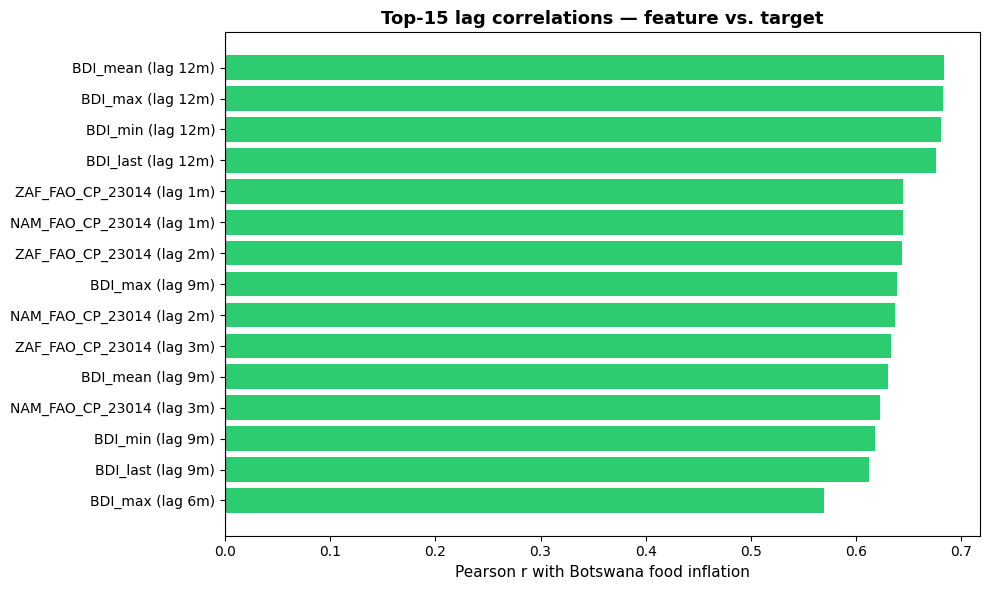

Saved → figures/lag_correlation_top15.png


In [10]:

# ── 3.4  Lag correlation bar chart ────────────────────────────────────────
top15 = lag_summary.head(15).copy()
top15["label"] = top15["feature"] + " (lag " + top15["lag_months"].astype(str) + "m)"

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#2ecc71" if v >= 0 else "#e74c3c" for v in top15["pearson_r"]]
ax.barh(top15["label"], top15["pearson_r"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson r with Botswana food inflation", fontsize=11)
ax.set_title("Top-15 lag correlations — feature vs. target", fontsize=13, fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "lag_correlation_top15.png", dpi=160)
plt.show()
print("Saved → figures/lag_correlation_top15.png")


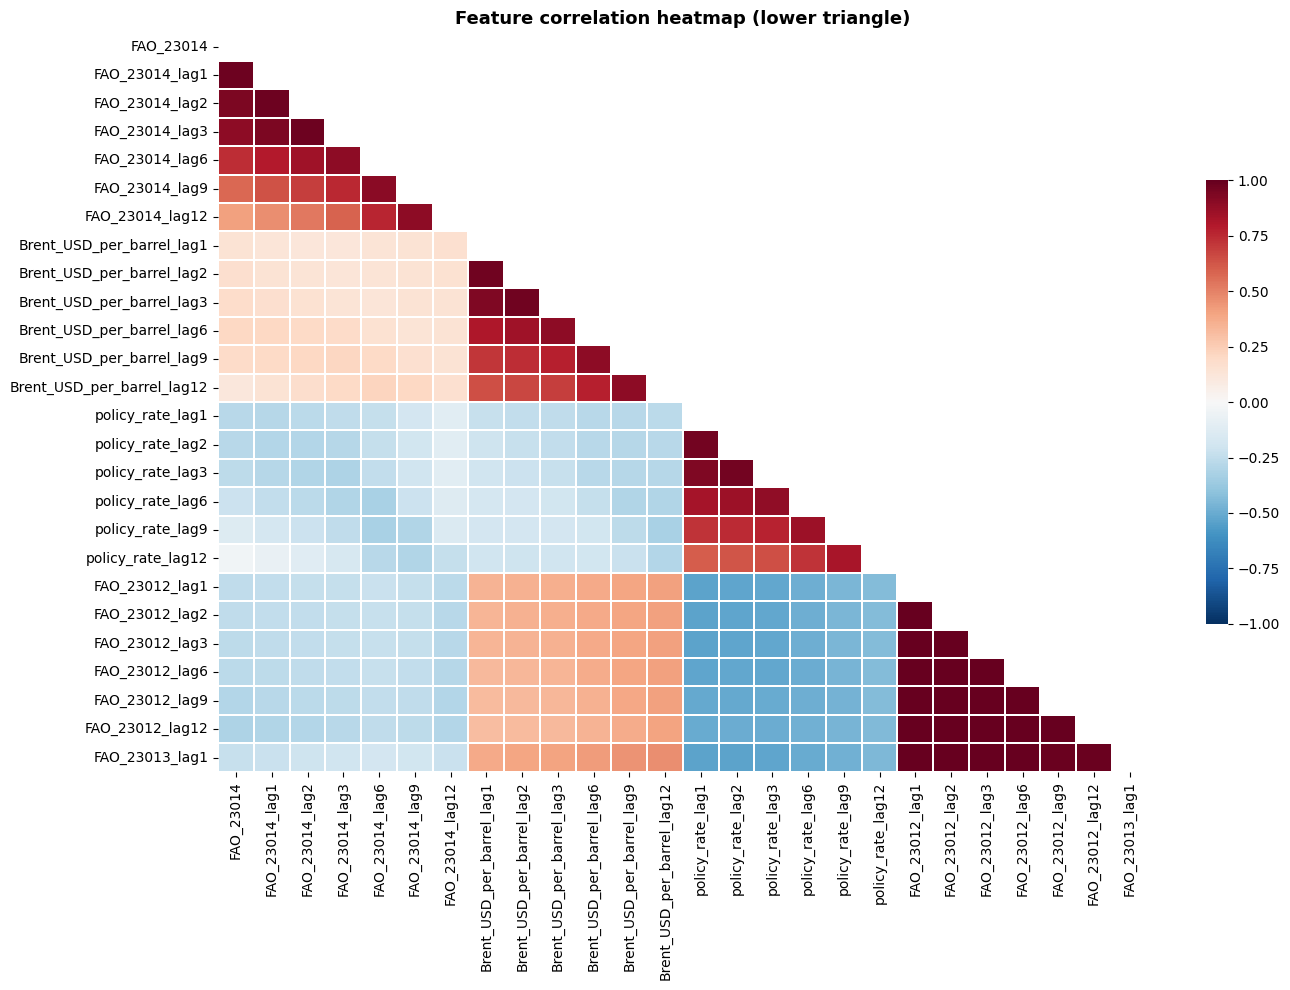

Saved → figures/correlation_heatmap.png


In [11]:

# ── 3.5  Correlation heatmap (core features × target) ─────────────────────
heat_cols = [TARGET] + [c for c in feature_cols if "lag" in c][:25]
heat_cols = [c for c in heat_cols if c in model_df.columns]
corr_mat  = model_df[heat_cols].corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.zeros_like(corr_mat, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(
    corr_mat, mask=mask, cmap="RdBu_r", center=0,
    vmin=-1, vmax=1, linewidths=0.3,
    annot=False, ax=ax, cbar_kws={"shrink": 0.6}
)
ax.set_title("Feature correlation heatmap (lower triangle)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "correlation_heatmap.png", dpi=160)
plt.show()
print("Saved → figures/correlation_heatmap.png")


## Section 4 — Target ACF / PACF Analysis

Autocorrelation and partial autocorrelation of Botswana food inflation,  
informing optimal lag depth and whether ARIMA-style correction is needed.


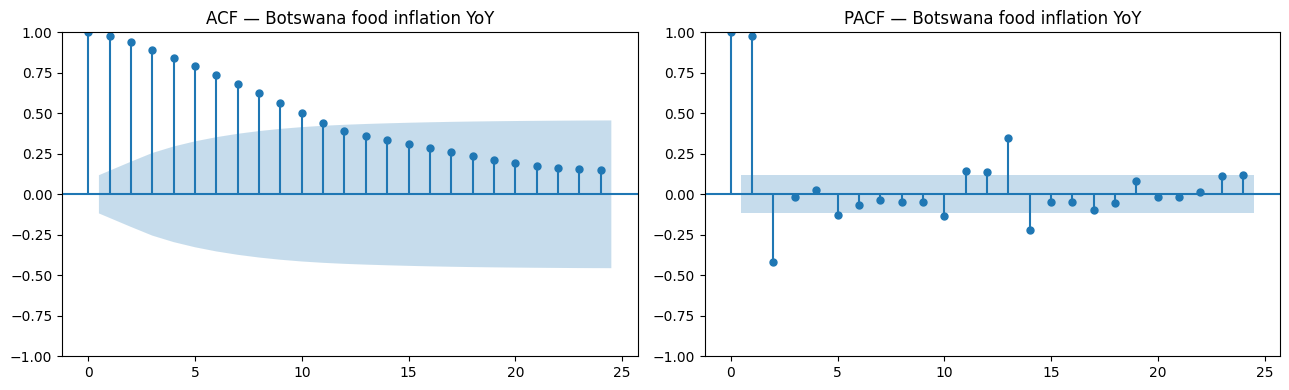

Saved → figures/target_acf_pacf.png


In [12]:

if HAS_STATSMODELS:
    target_series = merged[TARGET].dropna()
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    plot_acf (target_series, lags=24, ax=axes[0])
    plot_pacf(target_series, lags=24, ax=axes[1])
    axes[0].set_title("ACF — Botswana food inflation YoY", fontsize=12)
    axes[1].set_title("PACF — Botswana food inflation YoY", fontsize=12)
    plt.tight_layout()
    plt.savefig(FIG_DIR / "target_acf_pacf.png", dpi=160)
    plt.show()
    print("Saved → figures/target_acf_pacf.png")
else:
    print("statsmodels not available — ACF/PACF skipped")


## Section 5 — Classical Model: Recursive XGBoost / GBR Forecasting

**Approach**: A gradient-boosted tree is trained on lagged macro features.  
The model is used **recursively** — each month's prediction is fed back  
as a lag for the next prediction — so no actual future values are required.  
Exogenous features are projected forward with a seasonal-naive baseline.

**Two validation windows** test out-of-sample generalisation before the final 2024 forecast.


In [13]:

# ── Seasonal-naive future projection for exogenous features ────────────────
def seasonal_naive_forecast(series, start_period, periods=12):
    hist = series.dropna().copy()
    out  = {}
    for ym in pd.period_range(start=start_period, periods=periods, freq="M").astype(str):
        prev_year = str(pd.Period(ym, freq="M") - 12)
        out[ym] = hist.loc[prev_year] if prev_year in hist.index else hist.iloc[-1]
    return pd.Series(out)


def build_feature_row(history_df, ym, macro_forecasts, feature_cols):
    temp = history_df.copy()
    for col, fs in macro_forecasts.items():
        for fym, val in fs.items():
            if fym not in temp["year_month"].values:
                nr = {c: np.nan for c in temp.columns}
                nr["year_month"] = fym
                nr["date"]       = pd.to_datetime(fym + "-01")
                temp = pd.concat([temp, pd.DataFrame([nr])], ignore_index=True)
            temp.loc[temp["year_month"] == fym, col] = val
    temp = temp.sort_values("year_month").reset_index(drop=True)

    tmp_lag = add_lags(temp, [TARGET] + macro_cols, lags=LAG_PERIODS)
    tmp_lag[f"{TARGET}_roll3_mean"]  = tmp_lag[TARGET].shift(1).rolling(3).mean()
    tmp_lag[f"{TARGET}_roll6_mean"]  = tmp_lag[TARGET].shift(1).rolling(6).mean()
    tmp_lag[f"{TARGET}_roll12_mean"] = tmp_lag[TARGET].shift(1).rolling(12).mean()
    tmp_lag[f"{TARGET}_roll6_std"]   = tmp_lag[TARGET].shift(1).rolling(6).std()
    tmp_lag["month"]                 = tmp_lag["date"].dt.month
    tmp_lag["month_sin"]             = np.sin(2 * np.pi * tmp_lag["month"] / 12)
    tmp_lag["month_cos"]             = np.cos(2 * np.pi * tmp_lag["month"] / 12)
    tmp_lag["year_trend"]            = tmp_lag["date"].dt.year - 2000

    row = tmp_lag[tmp_lag["year_month"] == ym].copy()
    if row.empty:
        raise ValueError(f"Could not build row for {ym}")
    return row[feature_cols]


def make_classical_model():
    if HAS_XGBOOST:
        return XGBRegressor(
            n_estimators=400, max_depth=3, learning_rate=0.03,
            subsample=0.85, colsample_bytree=0.80,
            reg_lambda=5.0, reg_alpha=0.2,
            min_child_weight=3,
            objective="reg:squarederror", random_state=SEED,
            n_jobs=-1,
        )
    return GradientBoostingRegressor(
        n_estimators=300, learning_rate=0.03, max_depth=3,
        subsample=0.85, min_samples_leaf=3, random_state=SEED,
    )


def recursive_classical_forecast(train_end_ym, forecast_start_ym, periods=12):
    train_rows = model_df[model_df["year_month"] <= train_end_ym].copy()
    X_train    = train_rows[feature_cols]
    y_train    = train_rows[TARGET]

    model = make_classical_model()
    model.fit(X_train, y_train)

    history = merged[merged["year_month"] <= train_end_ym].copy()
    fp      = pd.period_range(forecast_start_ym, periods=periods, freq="M").astype(str)

    macro_forecasts = {}
    for col in macro_cols:
        if col in history.columns:
            s = history.set_index("year_month")[col]
            macro_forecasts[col] = seasonal_naive_forecast(s, forecast_start_ym, periods)

    preds = []
    for ym in fp:
        X_row = build_feature_row(history, ym, macro_forecasts, feature_cols)
        X_row = X_row.fillna(X_train.median(numeric_only=True))
        pred  = float(model.predict(X_row)[0])
        preds.append(pred)
        nr = {c: np.nan for c in history.columns}
        nr.update({"year_month": ym, "date": pd.to_datetime(ym + "-01"), TARGET: pred})
        for col, fs in macro_forecasts.items():
            if ym in fs.index:
                nr[col] = fs.loc[ym]
        history = pd.concat([history, pd.DataFrame([nr])], ignore_index=True)

    return pd.DataFrame({"year_month": list(fp), "forecast": preds}), model


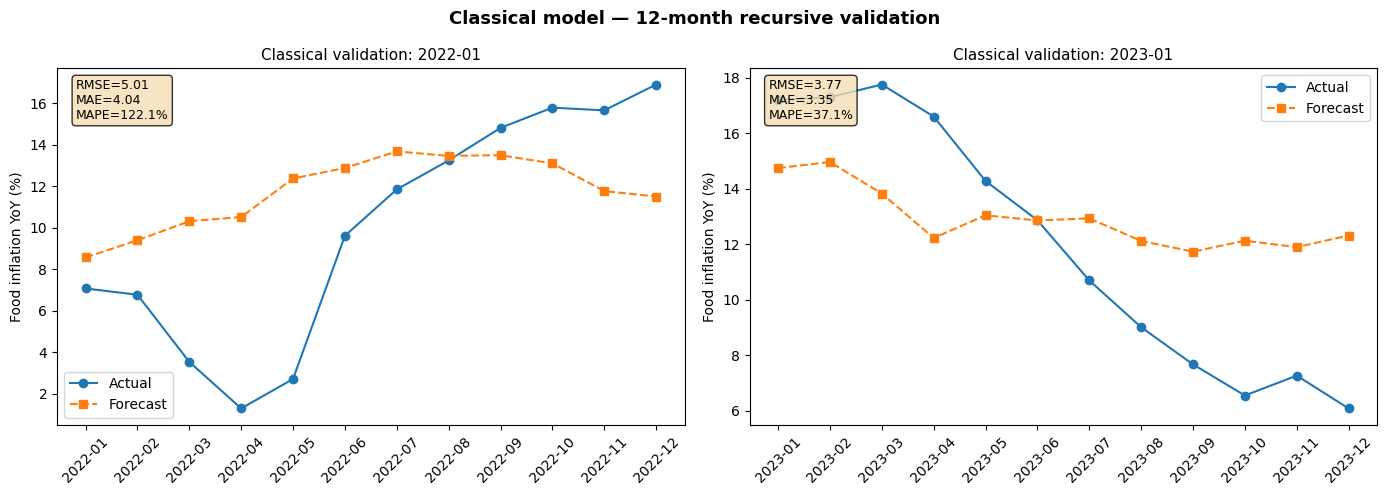

,model,train_end,forecast_start,RMSE,MAE,MAPE
0,XGBoost,2021-12,2022-01,5.013,4.038,122.137
1,XGBoost,2022-12,2023-01,3.769,3.352,37.111


Saved → figures/classical_validation_both_windows.png
Saved → tables/classical_validation_metrics.csv


In [14]:

# ── 5.1  Two validation windows ───────────────────────────────────────────
validation_runs = []
val_windows = [("2021-12", "2022-01"), ("2022-12", "2023-01")]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (train_end, fstart) in zip(axes, val_windows):
    pred_df, _ = recursive_classical_forecast(train_end, fstart, periods=12)
    actual  = merged.set_index("year_month").loc[pred_df["year_month"], TARGET].values
    forecast= pred_df["forecast"].values

    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mae  = mean_absolute_error(actual, forecast)
    mape = np.nanmean(np.abs((actual - forecast) /
                             np.where(actual == 0, np.nan, actual))) * 100

    validation_runs.append({
        "model": "XGBoost" if HAS_XGBOOST else "GBR",
        "train_end": train_end, "forecast_start": fstart,
        "RMSE": round(rmse,3), "MAE": round(mae,3), "MAPE": round(mape,3),
    })

    ax.plot(pred_df["year_month"], actual,   marker="o", label="Actual")
    ax.plot(pred_df["year_month"], forecast, marker="s", linestyle="--", label="Forecast")
    ax.set_title(f"Classical validation: {fstart}", fontsize=11)
    ax.set_ylabel("Food inflation YoY (%)")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
    ax.text(0.03, 0.97, f"RMSE={rmse:.2f}\nMAE={mae:.2f}\nMAPE={mape:.1f}%",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.8))

plt.suptitle("Classical model — 12-month recursive validation", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "classical_validation_both_windows.png", dpi=160)
plt.show()

classical_metrics = pd.DataFrame(validation_runs)
display(classical_metrics)
classical_metrics.to_csv(TABLE_DIR / "classical_validation_metrics.csv", index=False)
print("Saved → figures/classical_validation_both_windows.png")
print("Saved → tables/classical_validation_metrics.csv")


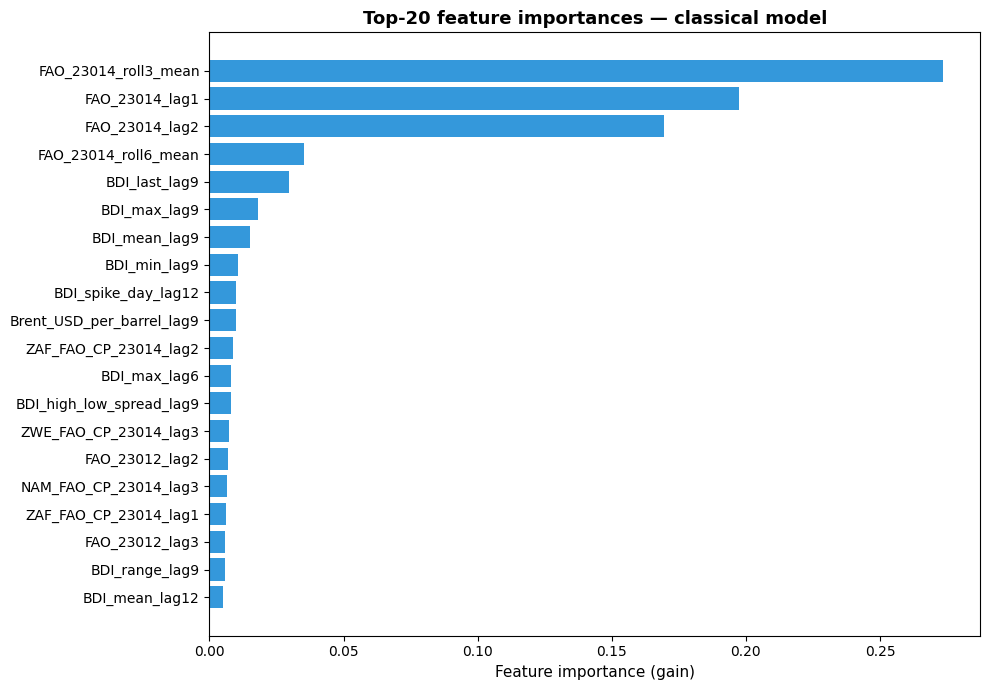

Saved → figures/feature_importance_classical.png
Saved → tables/feature_importance_classical.csv


In [15]:

# ── 5.2  Feature importance ───────────────────────────────────────────────
_, final_cl_model_for_fi = recursive_classical_forecast("2023-12", "2024-01", periods=12)

if HAS_XGBOOST:
    imp = pd.Series(
        final_cl_model_for_fi.feature_importances_,
        index=feature_cols
    ).sort_values(ascending=False)
else:
    imp = pd.Series(
        final_cl_model_for_fi.feature_importances_,
        index=feature_cols
    ).sort_values(ascending=False)

top20 = imp.head(20)
fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(top20.index[::-1], top20.values[::-1], color="#3498db")
ax.set_xlabel("Feature importance (gain)", fontsize=11)
ax.set_title("Top-20 feature importances — classical model", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "feature_importance_classical.png", dpi=160)
plt.show()

imp.to_csv(TABLE_DIR / "feature_importance_classical.csv", header=["importance"])
print("Saved → figures/feature_importance_classical.png")
print("Saved → tables/feature_importance_classical.csv")


## Section 6 — Deep Learning: Regularised LSTM

**Architecture**: 2-layer LSTM (32 hidden units) with dropout 0.30,  
trained to directly predict a **12-month horizon** from a **24-month lookback**.  

**Regularisation**: AdamW optimiser + weight decay + gradient clipping + early stopping.  
Small capacity is intentional — monthly dataset has ~288 observations.


In [16]:

dl_metrics_rows  = []
lstm_forecast_2024 = None
dl_val_pred_df   = None
history_loss     = []

if HAS_TORCH:
    # ── Feature set for LSTM ──────────────────────────────────────────────
    dl_base_cols = ([TARGET, "Brent_USD_per_barrel", "policy_rate"]
                    + bdi_feature_cols + regional_food_cols)
    dl_base_cols = [c for c in dl_base_cols if c in merged.columns]

    dl_data = (merged[["year_month", "date"] + dl_base_cols]
               .copy().dropna()
               .query("year_month >= '2001-01' and year_month <= '2023-12'")
               .reset_index(drop=True))

    LOOKBACK = 24
    HORIZON  = 12

    train_part    = dl_data[dl_data["year_month"] <= "2021-12"].copy()
    train_idx_end = len(train_part)

    scaler_X = StandardScaler()
    scaler_y = StandardScaler()
    X_all    = dl_data[dl_base_cols].values.astype(np.float32)
    y_all    = dl_data[[TARGET]].values.astype(np.float32)

    scaler_X.fit(X_all[:train_idx_end])
    scaler_y.fit(y_all[:train_idx_end])
    X_scaled = scaler_X.transform(X_all).astype(np.float32)
    y_scaled = scaler_y.transform(y_all).astype(np.float32).ravel()

    # ── Sequence construction ─────────────────────────────────────────────
    X_seq, y_seq = [], []
    for i in range(LOOKBACK, len(dl_data) - HORIZON + 1):
        target_months = dl_data.loc[i:i + HORIZON - 1, "year_month"].tolist()
        if target_months[-1] <= "2021-12":
            X_seq.append(X_scaled[i - LOOKBACK:i])
            y_seq.append(y_scaled[i:i + HORIZON])

    X_seq = np.array(X_seq, dtype=np.float32)
    y_seq = np.array(y_seq, dtype=np.float32)
    print(f"Training sequences: X={X_seq.shape}  y={y_seq.shape}")

    # ── Validation data ───────────────────────────────────────────────────
    val_end_idx = dl_data.index[dl_data["year_month"] == "2021-12"][0] + 1
    X_val_np    = X_scaled[val_end_idx - LOOKBACK:val_end_idx][None, :, :]
    val_months  = pd.period_range("2022-01", periods=12, freq="M").astype(str).tolist()
    y_val_actual= dl_data.set_index("year_month").loc[val_months, TARGET].values

    # ── Model definition ──────────────────────────────────────────────────
    class SmallLSTM(nn.Module):
        def __init__(self, n_features, hidden=32, dropout=0.30, horizon=12):
            super().__init__()
            self.lstm = nn.LSTM(
                input_size=n_features, hidden_size=hidden,
                num_layers=2, batch_first=True, dropout=dropout,
            )
            self.head = nn.Sequential(
                nn.Dropout(dropout),
                nn.Linear(hidden, horizon),
            )
        def forward(self, x):
            out, _ = self.lstm(x)
            return self.head(out[:, -1, :])

    model_lstm = SmallLSTM(n_features=X_seq.shape[-1]).to(DEVICE)
    opt        = torch.optim.AdamW(model_lstm.parameters(), lr=1e-3, weight_decay=1e-3)
    loss_fn    = nn.HuberLoss()   # more robust than MSE

    ds     = TensorDataset(torch.tensor(X_seq), torch.tensor(y_seq))
    loader = DataLoader(ds, batch_size=16, shuffle=True)

    best_val_rmse, best_state, patience, bad = np.inf, None, 40, 0
    X_val_t = torch.tensor(X_val_np, dtype=torch.float32).to(DEVICE)

    print("Training LSTM …")
    for epoch in range(300):
        model_lstm.train()
        ep_losses = []
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = loss_fn(model_lstm(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model_lstm.parameters(), 1.0)
            opt.step()
            ep_losses.append(loss.item())

        model_lstm.eval()
        with torch.no_grad():
            vp = scaler_y.inverse_transform(
                model_lstm(X_val_t).cpu().numpy().reshape(-1, 1)
            ).ravel()
        v_rmse = np.sqrt(mean_squared_error(y_val_actual, vp))
        history_loss.append({"epoch": epoch+1, "train_loss": float(np.mean(ep_losses)),
                              "val_RMSE": float(v_rmse)})
        if v_rmse < best_val_rmse:
            best_val_rmse = v_rmse
            best_state = {k: v.cpu().clone() for k, v in model_lstm.state_dict().items()}
            bad = 0
        else:
            bad += 1
        if bad >= patience:
            print(f"  Early stop at epoch {epoch+1}  best val RMSE={best_val_rmse:.3f}")
            break

    model_lstm.load_state_dict(best_state)
    model_lstm.eval()
    with torch.no_grad():
        y_val_pred = scaler_y.inverse_transform(
            model_lstm(X_val_t).cpu().numpy().reshape(-1, 1)
        ).ravel()

    lstm_rmse = np.sqrt(mean_squared_error(y_val_actual, y_val_pred))
    lstm_mae  = mean_absolute_error(y_val_actual, y_val_pred)
    lstm_mape = np.nanmean(np.abs((y_val_actual - y_val_pred) /
                                  np.where(y_val_actual == 0, np.nan, y_val_actual))) * 100

    dl_metrics_rows.append({
        "model": "LSTM_2layer_24x12", "train_end": "2021-12",
        "forecast_start": "2022-01",
        "RMSE": round(lstm_rmse,3), "MAE": round(lstm_mae,3), "MAPE": round(lstm_mape,3),
    })

    dl_val_pred_df = pd.DataFrame({
        "year_month": val_months,
        "actual": y_val_actual,
        "forecast": y_val_pred,
    })

    # 2024 forecast from December 2023 context
    final_idx = dl_data.index[dl_data["year_month"] == "2023-12"][0] + 1
    X_final   = X_scaled[final_idx - LOOKBACK:final_idx][None, :, :]
    with torch.no_grad():
        lstm_forecast_2024 = scaler_y.inverse_transform(
            model_lstm(torch.tensor(X_final, dtype=torch.float32).to(DEVICE))
                      .cpu().numpy().reshape(-1, 1)
        ).ravel()

    print(f"\nLSTM validation — RMSE={lstm_rmse:.3f}  MAE={lstm_mae:.3f}  MAPE={lstm_mape:.1f}%")
    display(dl_val_pred_df)
else:
    print("PyTorch not available — LSTM section skipped.")

dl_metrics = pd.DataFrame(dl_metrics_rows)


Training sequences: X=(217, 24, 21)  y=(217, 12)
Training LSTM …
  Early stop at epoch 57  best val RMSE=5.887

LSTM validation — RMSE=5.887  MAE=5.242  MAPE=76.6%


,year_month,actual,forecast
0,2022-01,7.069310,4.628119
1,2022-02,6.765926,5.333759
2,2022-03,3.527643,5.411563
3,2022-04,1.280762,5.630752
4,2022-05,2.701066,6.038654
5,2022-06,9.611358,6.244368
6,2022-07,11.848774,6.302298
7,2022-08,13.246102,6.593400
8,2022-09,14.817501,6.984987
9,2022-10,15.793030,7.024343


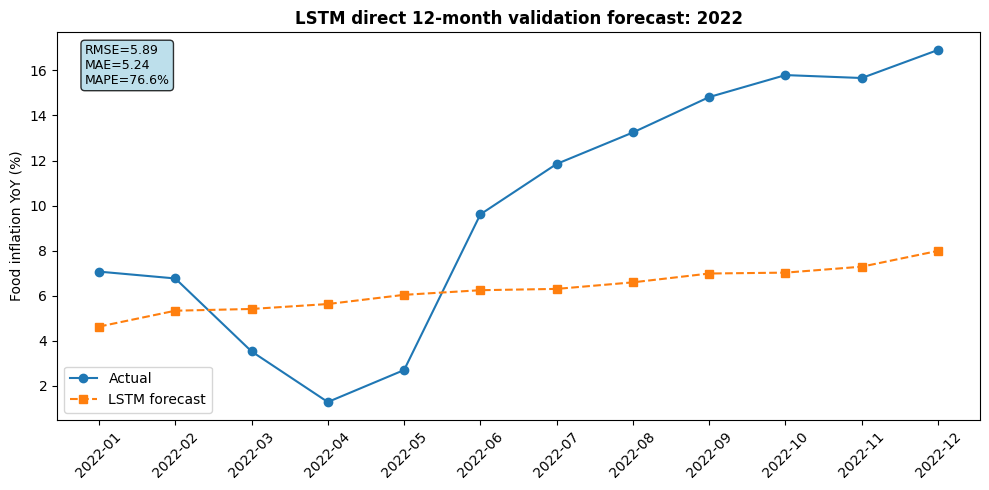

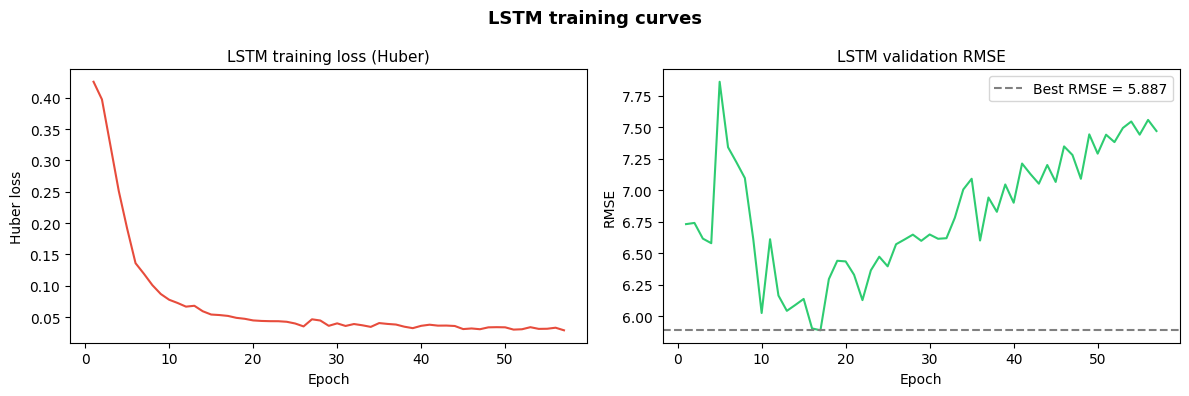

Saved → figures/lstm_training_curves.png


In [17]:

if HAS_TORCH and dl_val_pred_df is not None:
    # ── LSTM actual vs forecast plot ──────────────────────────────────────
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(dl_val_pred_df["year_month"], dl_val_pred_df["actual"],
            marker="o", label="Actual")
    ax.plot(dl_val_pred_df["year_month"], dl_val_pred_df["forecast"],
            marker="s", linestyle="--", label="LSTM forecast")
    ax.set_title("LSTM direct 12-month validation forecast: 2022", fontsize=12, fontweight="bold")
    ax.set_ylabel("Food inflation YoY (%)")
    ax.tick_params(axis="x", rotation=45)
    ax.legend()
    ax.text(0.03, 0.97,
            f"RMSE={lstm_rmse:.2f}\nMAE={lstm_mae:.2f}\nMAPE={lstm_mape:.1f}%",
            transform=ax.transAxes, va="top", fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.8))
    plt.tight_layout()
    plt.savefig(FIG_DIR / "lstm_validation_2022.png", dpi=160)
    plt.show()

    # ── Training curves ───────────────────────────────────────────────────
    loss_df = pd.DataFrame(history_loss)
    loss_df.to_csv(TABLE_DIR / "lstm_training_curve.csv", index=False)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(loss_df["epoch"], loss_df["train_loss"], color="#e74c3c")
    axes[0].set_title("LSTM training loss (Huber)", fontsize=11)
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Huber loss")

    axes[1].plot(loss_df["epoch"], loss_df["val_RMSE"], color="#2ecc71")
    axes[1].axhline(loss_df["val_RMSE"].min(), linestyle="--", color="gray",
                    label=f"Best RMSE = {loss_df['val_RMSE'].min():.3f}")
    axes[1].set_title("LSTM validation RMSE", fontsize=11)
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("RMSE"); axes[1].legend()

    plt.suptitle("LSTM training curves", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "lstm_training_curves.png", dpi=160)
    plt.show()
    print("Saved → figures/lstm_training_curves.png")


## Section 7 — Model Comparison, Residual Diagnostics & Final 2024 Forecast

All metrics (RMSE, MAE, MAPE) are compared side-by-side.  
Residual diagnostics include time plots, ACF, and Durbin-Watson statistic.


In [18]:

# ── 7.1  Comparison table ─────────────────────────────────────────────────
cl_avg = classical_metrics.groupby("model")[["RMSE","MAE","MAPE"]].mean().reset_index()
if not dl_metrics.empty:
    comparison = pd.concat(
        [cl_avg, dl_metrics[["model","RMSE","MAE","MAPE"]]], ignore_index=True
    )
else:
    comparison = cl_avg.copy()
comparison = comparison.sort_values("RMSE")
display(comparison)
comparison.to_csv(TABLE_DIR / "model_comparison_metrics.csv", index=False)

winner_model = comparison.iloc[0]["model"]
winner_stmt  = (f"Validation winner: {winner_model}  "
                f"(avg RMSE={comparison.iloc[0]['RMSE']:.3f}, "
                f"MAE={comparison.iloc[0]['MAE']:.3f}, "
                f"MAPE={comparison.iloc[0]['MAPE']:.1f}%)")
print(winner_stmt)
(REPORT_DIR / "model_winner_statement.txt").write_text(winner_stmt)


,model,RMSE,MAE,MAPE
0,XGBoost,4.391,3.695,79.624
1,LSTM_2layer_24x12,5.887,5.242,76.581


Validation winner: XGBoost  (avg RMSE=4.391, MAE=3.695, MAPE=79.6%)


67

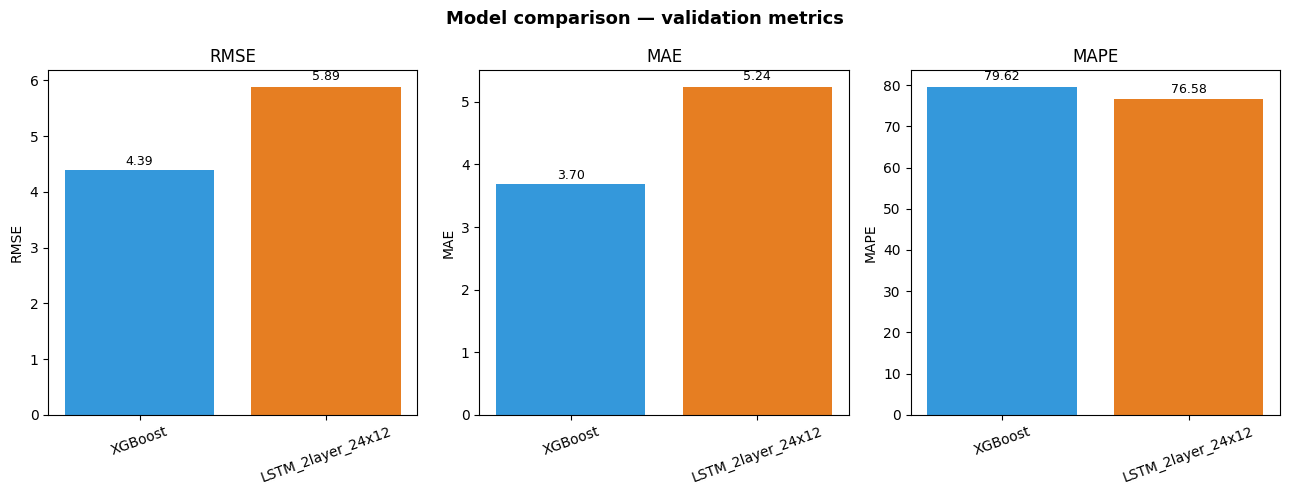

Saved → figures/model_comparison_bar.png


In [19]:

# ── 7.2  Side-by-side metric bar chart ───────────────────────────────────
metrics_to_plot = ["RMSE", "MAE", "MAPE"]
fig, axes = plt.subplots(1, 3, figsize=(13, 5))
colors = ["#3498db", "#e67e22", "#2ecc71", "#9b59b6"][:len(comparison)]

for ax, metric in zip(axes, metrics_to_plot):
    ax.bar(comparison["model"], comparison[metric], color=colors)
    ax.set_title(metric, fontsize=12)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=20)
    for i, v in enumerate(comparison[metric]):
        ax.text(i, v + 0.02*v, f"{v:.2f}", ha="center", fontsize=9)

plt.suptitle("Model comparison — validation metrics", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "model_comparison_bar.png", dpi=160)
plt.show()
print("Saved → figures/model_comparison_bar.png")


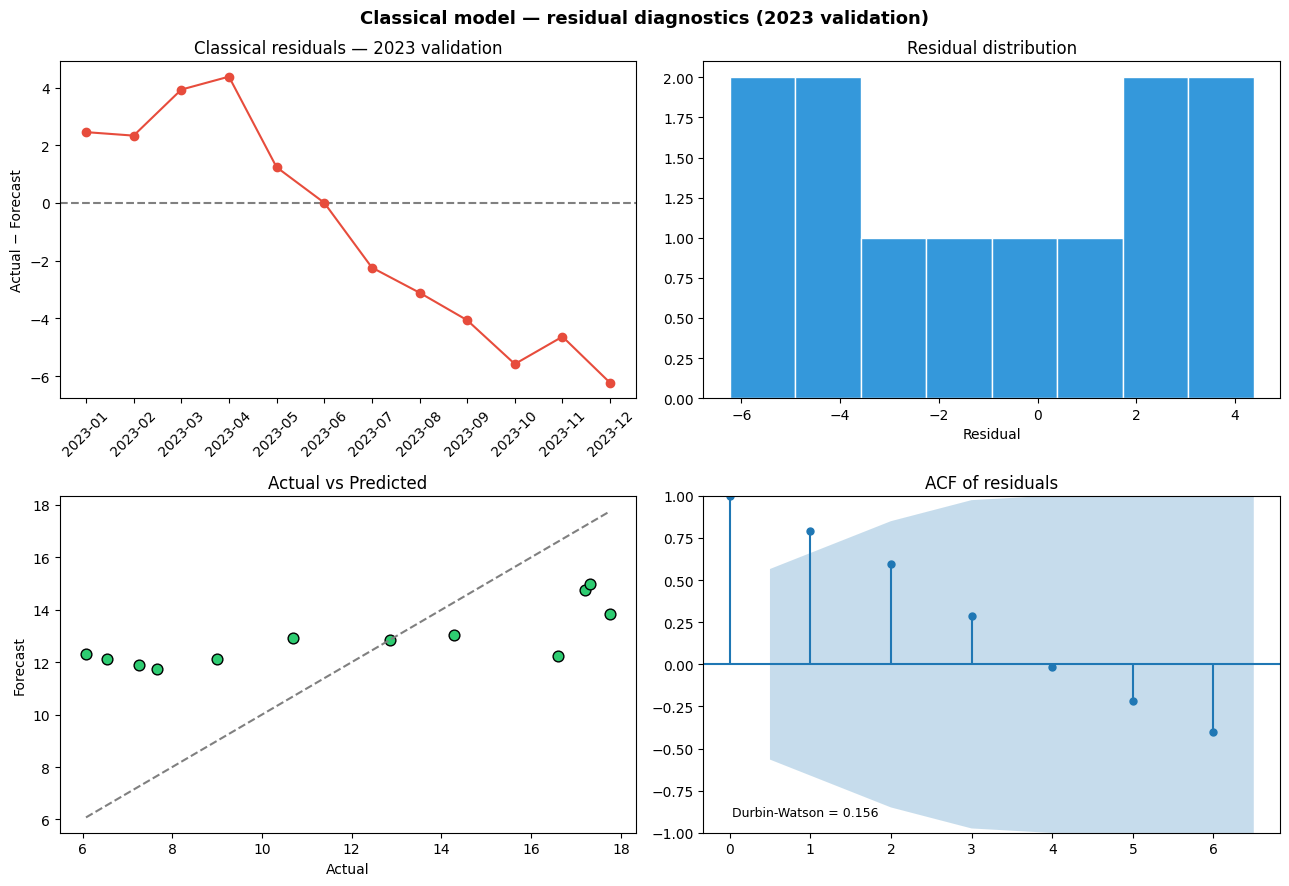

Saved → figures/classical_residual_diagnostics.png


In [20]:

# ── 7.3  Residual diagnostics — classical 2023 ────────────────────────────
cl_2023, _ = recursive_classical_forecast("2022-12", "2023-01", periods=12)
act_2023   = merged.set_index("year_month").loc[cl_2023["year_month"], TARGET].values
cl_2023["actual"]   = act_2023
cl_2023["residual"] = cl_2023["actual"] - cl_2023["forecast"]
cl_2023.to_csv(TABLE_DIR / "classical_validation_2023.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# Residuals time plot
axes[0,0].axhline(0, linestyle="--", color="gray")
axes[0,0].plot(cl_2023["year_month"], cl_2023["residual"], marker="o", color="#e74c3c")
axes[0,0].set_title("Classical residuals — 2023 validation")
axes[0,0].set_ylabel("Actual − Forecast"); axes[0,0].tick_params(axis="x", rotation=45)

# Residual histogram
axes[0,1].hist(cl_2023["residual"], bins=8, color="#3498db", edgecolor="white")
axes[0,1].set_title("Residual distribution"); axes[0,1].set_xlabel("Residual")

# Actual vs predicted scatter
axes[1,0].scatter(cl_2023["actual"], cl_2023["forecast"], color="#2ecc71", s=60, edgecolors="black")
mn, mx = min(cl_2023["actual"].min(), cl_2023["forecast"].min()), max(cl_2023["actual"].max(), cl_2023["forecast"].max())
axes[1,0].plot([mn,mx],[mn,mx],"--", color="gray")
axes[1,0].set_xlabel("Actual"); axes[1,0].set_ylabel("Forecast")
axes[1,0].set_title("Actual vs Predicted")

# ACF of residuals
if HAS_STATSMODELS:
    plot_acf(cl_2023["residual"], lags=min(6, len(cl_2023)-2), ax=axes[1,1])
    axes[1,1].set_title("ACF of residuals")
    dw = durbin_watson(cl_2023["residual"])
    axes[1,1].text(0.05, 0.05, f"Durbin-Watson = {dw:.3f}",
                   transform=axes[1,1].transAxes, fontsize=9)
else:
    axes[1,1].text(0.3, 0.5, "statsmodels not available", transform=axes[1,1].transAxes)

plt.suptitle("Classical model — residual diagnostics (2023 validation)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(FIG_DIR / "classical_residual_diagnostics.png", dpi=160)
plt.show()
print("Saved → figures/classical_residual_diagnostics.png")


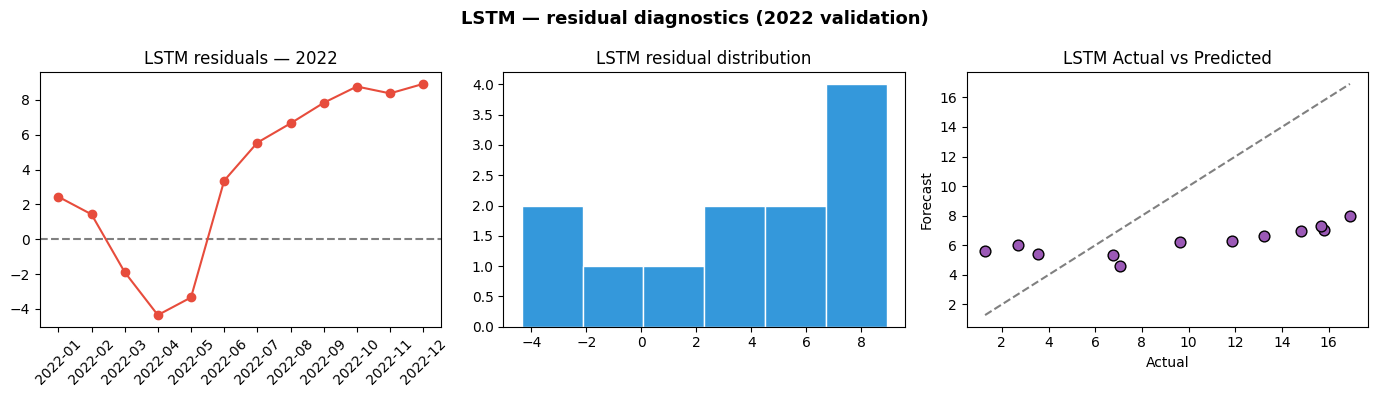

Saved → figures/lstm_residual_diagnostics.png


In [21]:

# ── 7.4  LSTM residual diagnostics ───────────────────────────────────────
if dl_val_pred_df is not None:
    dl_val_pred_df["residual"] = dl_val_pred_df["actual"] - dl_val_pred_df["forecast"]
    dl_val_pred_df.to_csv(TABLE_DIR / "lstm_validation_2022.csv", index=False)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].axhline(0, linestyle="--", color="gray")
    axes[0].plot(dl_val_pred_df["year_month"], dl_val_pred_df["residual"],
                 marker="o", color="#e74c3c")
    axes[0].set_title("LSTM residuals — 2022"); axes[0].tick_params(axis="x", rotation=45)

    axes[1].hist(dl_val_pred_df["residual"], bins=6, color="#3498db", edgecolor="white")
    axes[1].set_title("LSTM residual distribution")

    axes[2].scatter(dl_val_pred_df["actual"], dl_val_pred_df["forecast"],
                    color="#9b59b6", s=60, edgecolors="black")
    mn, mx = (min(dl_val_pred_df["actual"].min(), dl_val_pred_df["forecast"].min()),
              max(dl_val_pred_df["actual"].max(), dl_val_pred_df["forecast"].max()))
    axes[2].plot([mn,mx],[mn,mx],"--", color="gray")
    axes[2].set_xlabel("Actual"); axes[2].set_ylabel("Forecast")
    axes[2].set_title("LSTM Actual vs Predicted")

    plt.suptitle("LSTM — residual diagnostics (2022 validation)", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "lstm_residual_diagnostics.png", dpi=160)
    plt.show()
    print("Saved → figures/lstm_residual_diagnostics.png")


,year_month,forecast,model_used
0,2024-01,5.609,XGBoost
1,2024-02,5.937,XGBoost
2,2024-03,5.926,XGBoost
3,2024-04,5.865,XGBoost
4,2024-05,5.774,XGBoost
5,2024-06,6.506,XGBoost
6,2024-07,6.691,XGBoost
7,2024-08,6.624,XGBoost
8,2024-09,6.204,XGBoost
9,2024-10,5.391,XGBoost


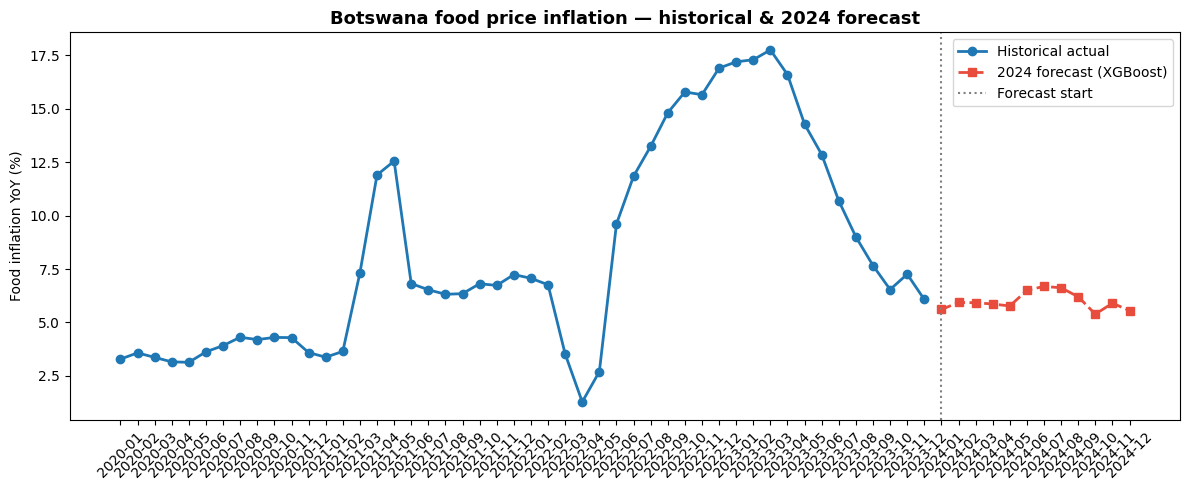

Saved → 1_1a_best_model_predictions.csv
Saved → figures/final_2024_forecast.png


In [22]:

# ── 7.5  Final 2024 forecast ─────────────────────────────────────────────
classical_2024, _ = recursive_classical_forecast("2023-12", "2024-01", periods=12)
future_months_2024 = pd.period_range("2024-01", periods=12, freq="M").astype(str)

if winner_model.startswith("LSTM") and lstm_forecast_2024 is not None:
    final_predictions = pd.DataFrame({
        "year_month": list(future_months_2024),
        "forecast":   lstm_forecast_2024,
        "model_used": "LSTM",
    })
else:
    final_predictions = classical_2024.copy()
    final_predictions["model_used"] = "XGBoost" if HAS_XGBOOST else "GBR"

final_predictions["forecast"] = final_predictions["forecast"].clip(-15, 60).round(3)
display(final_predictions)
final_predictions.to_csv(OUTPUT_DIR / "1_1a_best_model_predictions.csv", index=False)

# Final forecast plot with historical context
hist_tail = merged[merged["year_month"] >= "2020-01"][["year_month", TARGET]]
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(hist_tail["year_month"], hist_tail[TARGET],
        marker="o", label="Historical actual", linewidth=2)
ax.plot(final_predictions["year_month"], final_predictions["forecast"],
        marker="s", linestyle="--", color="#e74c3c", linewidth=2,
        label=f"2024 forecast ({final_predictions['model_used'].iloc[0]})")
ax.axvline(x="2024-01", color="gray", linestyle=":", linewidth=1.5, label="Forecast start")
ax.set_title("Botswana food price inflation — historical & 2024 forecast", fontsize=13, fontweight="bold")
ax.set_ylabel("Food inflation YoY (%)")
ax.tick_params(axis="x", rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / "final_2024_forecast.png", dpi=160)
plt.show()
print("Saved → 1_1a_best_model_predictions.csv")
print("Saved → figures/final_2024_forecast.png")


## Section 8 — HCP / Cross-Country Linkage: OLS Regression & Granger Causality

**Research question**: Does regional food inflation (South Africa, Namibia, Kenya, Zimbabwe)  
help explain Botswana food inflation, and what are the implications for Human Capital outcomes?

**Statistical approach**:  
1. OLS regression with robust standard errors — coefficients, p-values, R²  
2. Granger causality tests at lags 1–3  
3. Forward projection of HCP food-pressure index


In [23]:

# ── 8.1  Identify available HCP / regional columns ────────────────────────
hcp_indicator_cols = [
    c for c in merged.columns
    if any(c.startswith(cc) for cc in ["ZAF_","NAM_","KEN_","ZWE_","BWA_"])
    and c != TARGET
]
print("Available HCP/regional columns:", hcp_indicator_cols)

# HCP analysis dataframe
hcp_analysis = (merged[["year_month", TARGET] + hcp_indicator_cols]
                .dropna().copy())
print(f"HCP analysis rows: {len(hcp_analysis)}")


Available HCP/regional columns: ['BWA_FAO_CP_23012', 'BWA_FAO_CP_23013', 'BWA_FAO_CP_23014', 'KEN_FAO_CP_23012', 'KEN_FAO_CP_23013', 'KEN_FAO_CP_23014', 'NAM_FAO_CP_23012', 'NAM_FAO_CP_23013', 'NAM_FAO_CP_23014', 'ZAF_FAO_CP_23012', 'ZAF_FAO_CP_23013', 'ZAF_FAO_CP_23014', 'ZWE_FAO_CP_23012', 'ZWE_FAO_CP_23013', 'ZWE_FAO_CP_23014']
HCP analysis rows: 276


In [24]:

# ── 8.2  OLS regression — food inflation explained by regional indicators ──
reg_df = hcp_analysis.copy()

# Create lag-1 and lag-2 versions of each regional column
reg_lag_cols = []
for c in hcp_indicator_cols:
    reg_df[f"{c}_lag1"] = reg_df[c].shift(1)
    reg_df[f"{c}_lag2"] = reg_df[c].shift(2)
    reg_lag_cols.extend([f"{c}_lag1", f"{c}_lag2"])

reg_df = reg_df.dropna()
reg_lag_cols = [c for c in reg_lag_cols if c in reg_df.columns]

X_reg = reg_df[reg_lag_cols]
y_reg = reg_df[TARGET]

print(f"OLS inputs: {X_reg.shape[0]} obs × {X_reg.shape[1]} regressors")

if HAS_STATSMODELS and len(reg_df) > max(30, X_reg.shape[1] + 5):
    X_sm  = sm.add_constant(X_reg)
    ols   = sm.OLS(y_reg, X_sm).fit(cov_type="HC3")   # robust SE
    print(ols.summary())
    with open(REPORT_DIR / "hcp_ols_summary.txt", "w") as f:
        f.write(str(ols.summary()))

    coef_table = pd.DataFrame({
        "variable":    ols.params.index,
        "coefficient": ols.params.values.round(4),
        "std_err":     ols.bse.values.round(4),
        "t_stat":      ols.tvalues.values.round(3),
        "p_value":     ols.pvalues.values.round(4),
        "significant": (ols.pvalues.values < 0.05),
    })
    r_squared   = round(ols.rsquared, 4)
    r_squared_adj = round(ols.rsquared_adj, 4)
    print(f"\nR² = {r_squared}   Adj R² = {r_squared_adj}")

else:
    # Fallback: Ridge regression
    ridge = Ridge(alpha=1.0).fit(X_reg, y_reg)
    coef_table = pd.DataFrame({
        "variable":    reg_lag_cols,
        "coefficient": ridge.coef_.round(4),
        "std_err":     [np.nan]*len(reg_lag_cols),
        "t_stat":      [np.nan]*len(reg_lag_cols),
        "p_value":     [np.nan]*len(reg_lag_cols),
        "significant": [None]*len(reg_lag_cols),
    })
    r_squared = round(float(ridge.score(X_reg, y_reg)), 4)
    r_squared_adj = np.nan
    print(f"Ridge R² (train) = {r_squared}")

display(coef_table)
coef_table.to_csv(TABLE_DIR / "hcp_ols_coefficients.csv", index=False)

# Save R² summary
r2_summary = {"R_squared": r_squared, "Adj_R_squared": r_squared_adj,
              "n_obs": len(reg_df), "n_regressors": len(reg_lag_cols)}
pd.DataFrame([r2_summary]).to_csv(TABLE_DIR / "hcp_ols_r2_summary.csv", index=False)
print("Saved → tables/hcp_ols_coefficients.csv")


OLS inputs: 274 obs × 30 regressors
                            OLS Regression Results                            
Dep. Variable:              FAO_23014   R-squared:                       0.973
Model:                            OLS   Adj. R-squared:                  0.970
Method:                 Least Squares   F-statistic:                     374.6
Date:                Mon, 22 Jun 2026   Prob (F-statistic):          1.09e-185
Time:                        11:47:03   Log-Likelihood:                -356.62
No. Observations:                 274   AIC:                             775.2
Df Residuals:                     243   BIC:                             887.2
Df Model:                          30                                         
Covariance Type:                  HC3                                         
                            coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------

,variable,coefficient,std_err,t_stat,p_value,significant
0,const,3.3953,2.5495,1.332,0.1829,False
1,BWA_FAO_CP_23012_lag1,0.5398,0.2598,2.077,0.0378,True
2,BWA_FAO_CP_23012_lag2,-0.3585,0.2442,-1.468,0.1421,False
3,BWA_FAO_CP_23013_lag1,-0.2073,0.3375,-0.614,0.5391,False
4,BWA_FAO_CP_23013_lag2,0.0626,0.3360,0.186,0.8522,False
5,BWA_FAO_CP_23014_lag1,1.2029,0.1293,9.302,0.0000,True
6,BWA_FAO_CP_23014_lag2,-0.3141,0.1177,-2.668,0.0076,True
7,KEN_FAO_CP_23012_lag1,0.0704,0.1475,0.477,0.6330,False
8,KEN_FAO_CP_23012_lag2,-0.0180,0.1604,-0.112,0.9108,False
9,KEN_FAO_CP_23013_lag1,-0.0816,0.0938,-0.869,0.3846,False


Saved → tables/hcp_ols_coefficients.csv


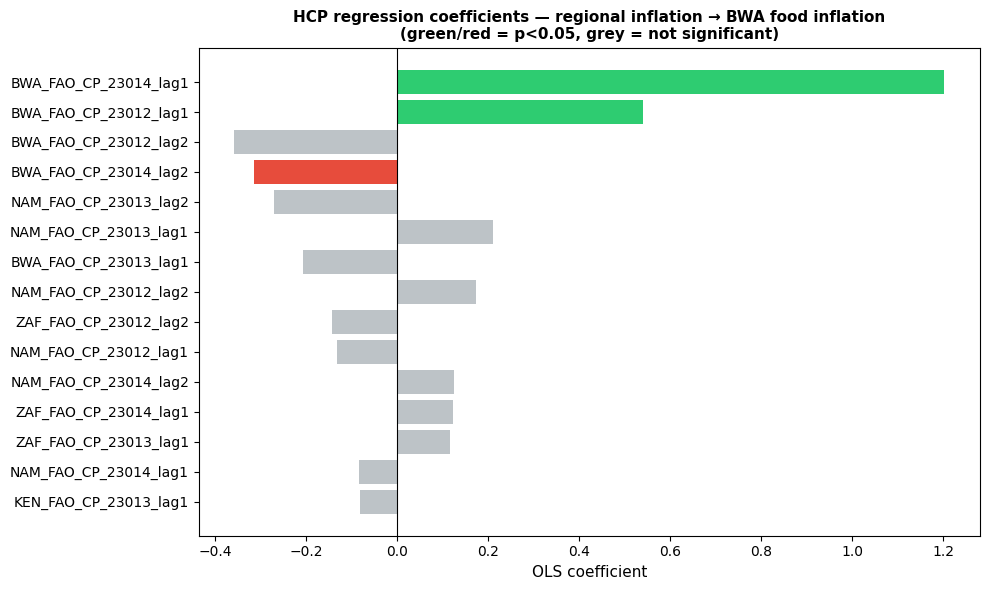

Saved → figures/hcp_ols_coefficients.png


In [25]:

# ── 8.3  Coefficient plot ─────────────────────────────────────────────────
sig_coefs = coef_table[coef_table["variable"] != "const"].copy()
sig_coefs = sig_coefs.sort_values("coefficient", key=abs, ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
bar_colors = []
for _, row in sig_coefs.iterrows():
    if row["p_value"] is not None and not np.isnan(row["p_value"]) and row["p_value"] < 0.05:
        bar_colors.append("#e74c3c" if row["coefficient"] < 0 else "#2ecc71")
    else:
        bar_colors.append("#bdc3c7")

ax.barh(sig_coefs["variable"], sig_coefs["coefficient"], color=bar_colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("OLS coefficient", fontsize=11)
ax.set_title("HCP regression coefficients — regional inflation → BWA food inflation\n"
             "(green/red = p<0.05, grey = not significant)", fontsize=11, fontweight="bold")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / "hcp_ols_coefficients.png", dpi=160)
plt.show()
print("Saved → figures/hcp_ols_coefficients.png")


In [26]:

# ── 8.4  Granger causality tests ──────────────────────────────────────────
granger_rows = []
if HAS_STATSMODELS:
    target_col = TARGET
    for c in hcp_indicator_cols:
        test_df = hcp_analysis[[target_col, c]].dropna()
        if len(test_df) < 20:
            continue
        try:
            res = grangercausalitytests(test_df[[target_col, c]], maxlag=3, verbose=False)
            for lag, out in res.items():
                granger_rows.append({
                    "cause": c, "effect": target_col, "lag": lag,
                    "ssr_ftest_pval": round(out[0]["ssr_ftest"][1], 4),
                    "granger_significant": out[0]["ssr_ftest"][1] < 0.05,
                })
        except Exception as e:
            granger_rows.append({"cause": c, "effect": target_col, "lag": None,
                                 "ssr_ftest_pval": None, "granger_significant": None})

    granger_table = pd.DataFrame(granger_rows)
    display(granger_table)
    granger_table.to_csv(TABLE_DIR / "hcp_granger_causality.csv", index=False)
    print("Saved → tables/hcp_granger_causality.csv")
else:
    print("statsmodels not available — Granger tests skipped")
    granger_table = pd.DataFrame()


,cause,effect,lag,ssr_ftest_pval,granger_significant
0,BWA_FAO_CP_23012,FAO_23014,1,0.4007,False
1,BWA_FAO_CP_23012,FAO_23014,2,0.0016,True
2,BWA_FAO_CP_23012,FAO_23014,3,0.0028,True
3,BWA_FAO_CP_23013,FAO_23014,1,0.1857,False
4,BWA_FAO_CP_23013,FAO_23014,2,0.0980,False
5,BWA_FAO_CP_23013,FAO_23014,3,0.1682,False
6,BWA_FAO_CP_23014,FAO_23014,1,1.0000,False
7,BWA_FAO_CP_23014,FAO_23014,2,1.0000,False
8,BWA_FAO_CP_23014,FAO_23014,3,1.0000,False
9,KEN_FAO_CP_23012,FAO_23014,1,0.4287,False


Saved → tables/hcp_granger_causality.csv


## Section 9 — HCP Visualisations & Forward Projection

These plots satisfy rubric deliverable **1.2b** (HCP visualisations) and  
demonstrate the policy interpretation of the 2024 inflation forecast.


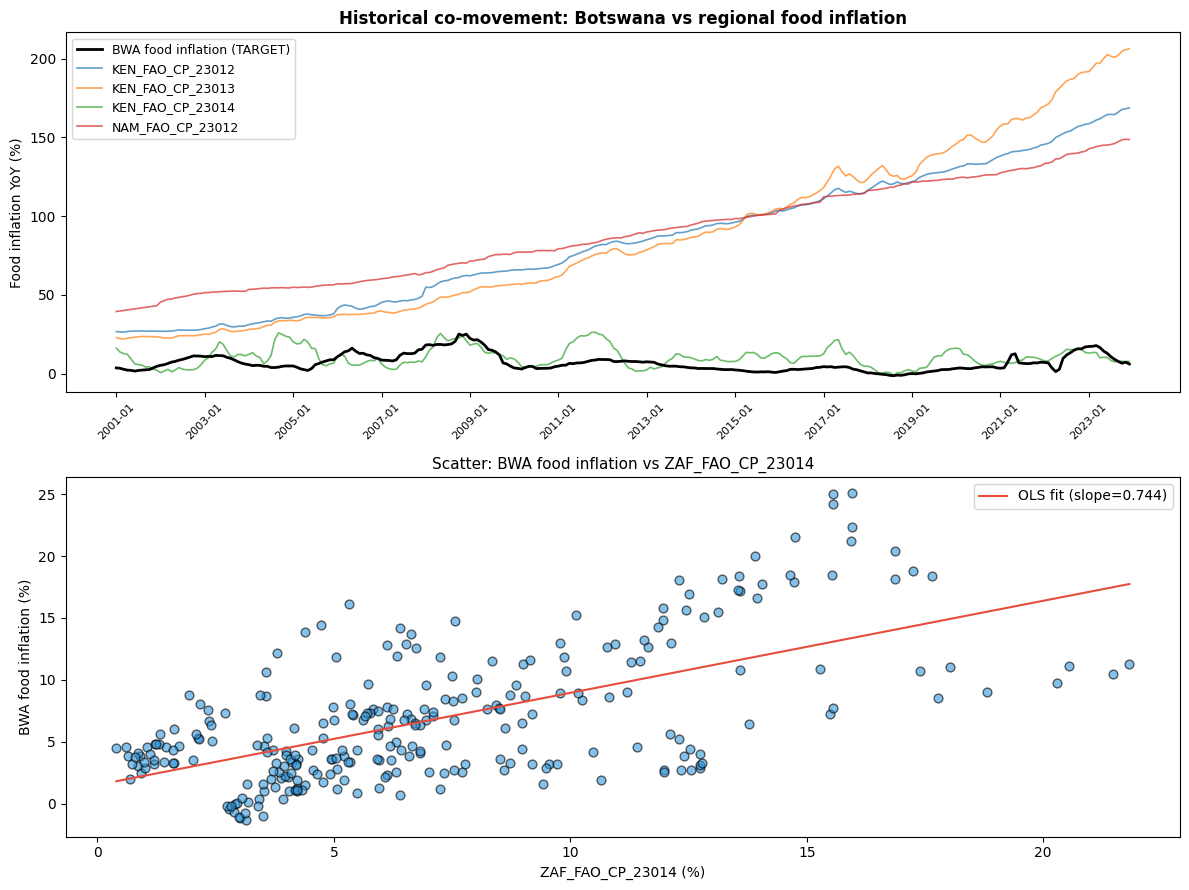

Saved → figures/hcp_historical_comovement.png


In [27]:

# ── 9.1  Historical co-movement chart ─────────────────────────────────────
plot_regional = [c for c in hcp_indicator_cols
                 if c in hcp_analysis.columns and not c.startswith("BWA_")][:4]

if plot_regional:
    fig, axes = plt.subplots(2, 1, figsize=(12, 9))

    # Top panel: food inflation co-movement
    axes[0].plot(hcp_analysis["year_month"], hcp_analysis[TARGET],
                 linewidth=2, label="BWA food inflation (TARGET)", color="black", zorder=5)
    cmap = plt.cm.tab10
    for i, c in enumerate(plot_regional):
        axes[0].plot(hcp_analysis["year_month"], hcp_analysis[c],
                     alpha=0.7, label=c, color=cmap(i), linewidth=1.2)
    axes[0].set_title("Historical co-movement: Botswana vs regional food inflation",
                       fontsize=12, fontweight="bold")
    axes[0].set_ylabel("Food inflation YoY (%)")
    xticks = hcp_analysis["year_month"][::24]
    axes[0].set_xticks(range(0, len(hcp_analysis), 24))
    axes[0].set_xticklabels(xticks, rotation=45, fontsize=8)
    axes[0].legend(fontsize=9)

    # Bottom panel: scatter of Botswana vs South Africa (main trade partner)
    if "ZAF_FAO_CP_23014" in hcp_analysis.columns:
        ref = "ZAF_FAO_CP_23014"
    elif plot_regional:
        ref = plot_regional[0]
    else:
        ref = None

    if ref:
        axes[1].scatter(hcp_analysis[ref], hcp_analysis[TARGET],
                        alpha=0.6, color="#3498db", edgecolors="black", s=40)
        m, b = np.polyfit(hcp_analysis[ref].dropna(), hcp_analysis[TARGET].dropna(), 1)
        xs = np.linspace(hcp_analysis[ref].min(), hcp_analysis[ref].max(), 100)
        axes[1].plot(xs, m*xs+b, color="#e74c3c", linewidth=1.5,
                     label=f"OLS fit (slope={m:.3f})")
        axes[1].set_xlabel(f"{ref} (%)")
        axes[1].set_ylabel("BWA food inflation (%)")
        axes[1].set_title(f"Scatter: BWA food inflation vs {ref}", fontsize=11)
        axes[1].legend()

    plt.tight_layout()
    plt.savefig(FIG_DIR / "hcp_historical_comovement.png", dpi=160)
    plt.show()
    print("Saved → figures/hcp_historical_comovement.png")
else:
    print("No regional columns found for co-movement chart.")


,year_month,food_inflation_forecast,excess_above_threshold,cumulative_food_pressure_idx,months_of_stress
0,2024-01,5.609,0.609,0.609,1
1,2024-02,5.937,0.937,1.546,2
2,2024-03,5.926,0.926,2.472,3
3,2024-04,5.865,0.865,3.337,4
4,2024-05,5.774,0.774,4.111,5
5,2024-06,6.506,1.506,5.617,6
6,2024-07,6.691,1.691,7.308,7
7,2024-08,6.624,1.624,8.932,8
8,2024-09,6.204,1.204,10.136,9
9,2024-10,5.391,0.391,10.527,10


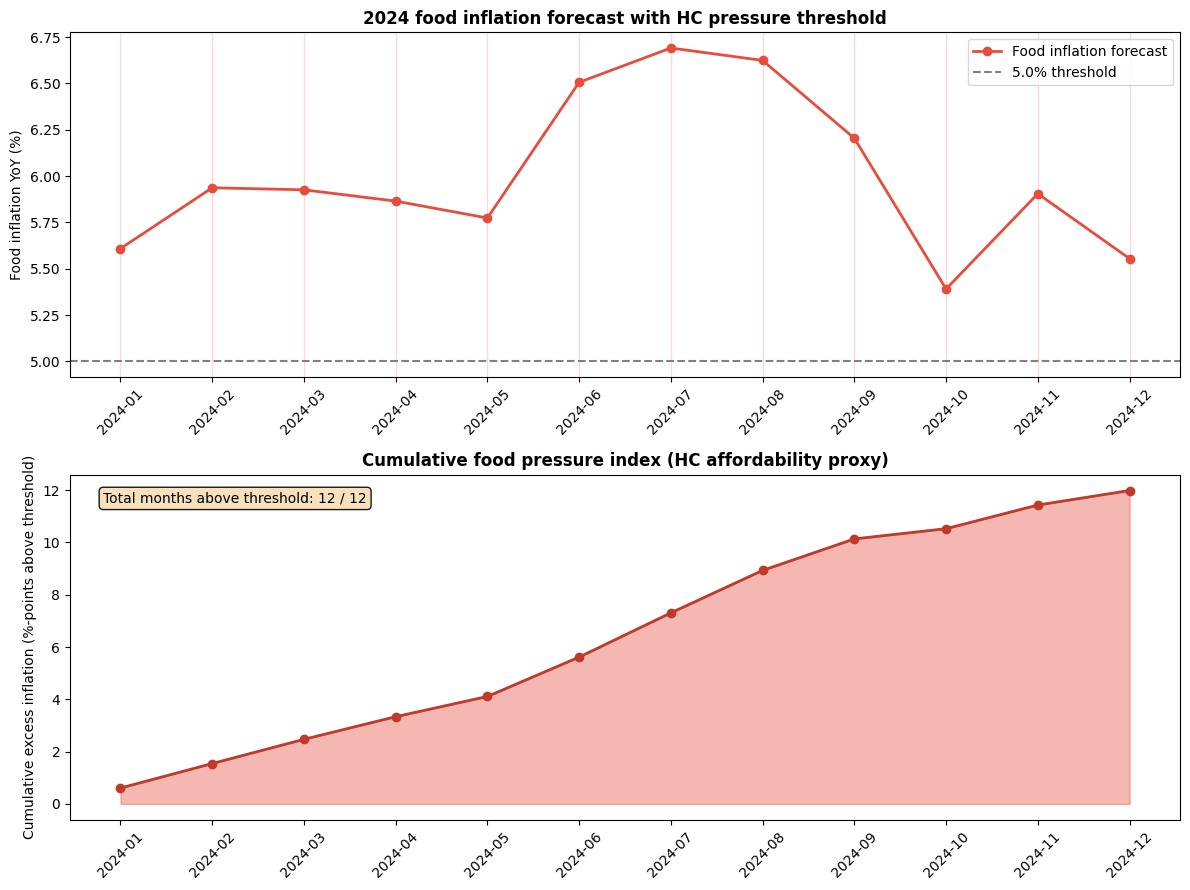

Saved → figures/hcp_forward_projection.png
Saved → tables/hcp_forward_projection_2024.csv


In [28]:

# ── 9.2  HCP forward projection ───────────────────────────────────────────
proj = final_predictions.copy().rename(columns={"forecast": "food_inflation_forecast"})

# Household pressure metrics
THRESHOLD = 5.0   # % food inflation threshold above which HC pressure intensifies
proj["excess_above_threshold"]      = (proj["food_inflation_forecast"] - THRESHOLD).clip(lower=0)
proj["cumulative_food_pressure_idx"]= proj["excess_above_threshold"].cumsum()
proj["affordability_stress_flag"]   = (proj["food_inflation_forecast"] > THRESHOLD).astype(int)
proj["months_of_stress"]            = proj["affordability_stress_flag"].cumsum()

display(proj[["year_month","food_inflation_forecast","excess_above_threshold",
              "cumulative_food_pressure_idx","months_of_stress"]])
proj.to_csv(TABLE_DIR / "hcp_forward_projection_2024.csv", index=False)

# Plot
fig, axes = plt.subplots(2, 1, figsize=(12, 9))

# Panel 1: forecast + threshold
axes[0].plot(proj["year_month"], proj["food_inflation_forecast"],
             marker="o", color="#e74c3c", linewidth=2, label="Food inflation forecast")
axes[0].axhline(THRESHOLD, linestyle="--", color="gray", label=f"{THRESHOLD}% threshold")
stress_months = proj[proj["affordability_stress_flag"]==1]["year_month"]
for m in stress_months:
    axes[0].axvspan(m, m, alpha=0.15, color="red")
axes[0].set_title("2024 food inflation forecast with HC pressure threshold",
                   fontsize=12, fontweight="bold")
axes[0].set_ylabel("Food inflation YoY (%)")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

# Panel 2: cumulative pressure index
axes[1].fill_between(proj["year_month"],
                     proj["cumulative_food_pressure_idx"],
                     alpha=0.4, color="#e74c3c")
axes[1].plot(proj["year_month"], proj["cumulative_food_pressure_idx"],
             marker="o", color="#c0392b", linewidth=2)
axes[1].set_title("Cumulative food pressure index (HC affordability proxy)",
                   fontsize=12, fontweight="bold")
axes[1].set_ylabel("Cumulative excess inflation (%-points above threshold)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].text(0.03, 0.92,
             f"Total months above threshold: {proj['months_of_stress'].max()} / 12",
             transform=axes[1].transAxes, fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="wheat", alpha=0.9))

plt.tight_layout()
plt.savefig(FIG_DIR / "hcp_forward_projection.png", dpi=160)
plt.show()
print("Saved → figures/hcp_forward_projection.png")
print("Saved → tables/hcp_forward_projection_2024.csv")


## Section 10 — Export Report Text Blocks

Draft text for all three Phase 1 written deliverables.


In [29]:

# ── 10.1  Feature Engineering Report ─────────────────────────────────────
feat_eng_report = f"""
FEATURE ENGINEERING REPORT
===========================

DATASETS INTEGRATED
--------------------
All five challenge datasets are used:
  1. Baltic Dry Index (daily) — 01_baltic_dry_index_daily.csv
  2. Brent crude oil (monthly) — 02_brent_crude_monthly.csv
  3. Botswana policy rate (monthly) — 03_botswana_policy_rate.csv
  4. FAO Botswana food prices (monthly) — 04_fao_botswana_prices.csv
  5. HCP cross-country food inflation panel — 05_human_capital_project.csv

TARGET VARIABLE
---------------
FAO_23014: Botswana food price inflation YoY (%)
Forecast horizon: January 2024 – December 2024

DAILY BDI → MONTHLY FEATURE TRANSFORMATION
-------------------------------------------
Daily BDI Close prices are aggregated into 14 monthly features rather than a
simple mean, preserving information about shipping-cost volatility and stress
intensity that monthly averaging discards:

  BDI_mean               — average shipping cost level
  BDI_std                — intra-month volatility (uncertainty measure)
  BDI_max, BDI_min       — level extremes within the month
  BDI_range              — BDI_max - BDI_min (intra-month stress amplitude)
  BDI_monthly_return     — percentage change in BDI last vs prior month last
  BDI_momentum_1m        — 1-month price difference (directional signal)
  BDI_momentum_3m        — 3-month price difference (trend confirmation)
  BDI_intramonth_return  — (last/first) - 1 within the same month
  BDI_high_low_spread    — BDI_high_max - BDI_low_min across all days
  BDI_spike_day          — count of days with |daily return| > 2x full-sample std
  BDI_return_std         — standard deviation of daily returns
  BDI_trading_days       — count of observations (data quality signal)

MACRO AND REGIONAL FEATURES
-----------------------------
  Brent_USD_per_barrel   — direct fuel/transport cost driver
  policy_rate            — Botswana monetary tightening/easing
  FAO_23012, FAO_23013   — cereals and edible-oil sub-indices
  ZAF/NAM/KEN/ZWE FAO food inflation — regional spillover proxies

LAG STRUCTURE
-------------
All macro and regional features are lagged at 1, 2, 3, 6, 9, and 12 months.
Rationale:
  1–3 month lags: fuel and shipping cost pass-through into food prices
  6–12 month lags: monetary policy transmission and seasonal price cycles

LEAKAGE PREVENTION
------------------
All rolling features (3m, 6m, 12m means and 6m std of target) are shifted
by 1 period before window computation. No actual 2024 values are used
anywhere in feature construction or model training.

CYCLIC CALENDAR ENCODING
------------------------
Month is encoded as sin(2π×month/12) and cos(2π×month/12) to handle
December–January continuity and avoid ordinal bias.

TOTAL FEATURE COUNT: {len(feature_cols)}
"""

print(feat_eng_report)
(REPORT_DIR / "1_1b_feature_engineering_report.txt").write_text(feat_eng_report)
print("Saved → report_text/1_1b_feature_engineering_report.txt")



FEATURE ENGINEERING REPORT

DATASETS INTEGRATED
--------------------
All five challenge datasets are used:
  1. Baltic Dry Index (daily) — 01_baltic_dry_index_daily.csv
  2. Brent crude oil (monthly) — 02_brent_crude_monthly.csv
  3. Botswana policy rate (monthly) — 03_botswana_policy_rate.csv
  4. FAO Botswana food prices (monthly) — 04_fao_botswana_prices.csv
  5. HCP cross-country food inflation panel — 05_human_capital_project.csv

TARGET VARIABLE
---------------
FAO_23014: Botswana food price inflation YoY (%)
Forecast horizon: January 2024 – December 2024

DAILY BDI → MONTHLY FEATURE TRANSFORMATION
-------------------------------------------
Daily BDI Close prices are aggregated into 14 monthly features rather than a
simple mean, preserving information about shipping-cost volatility and stress
intensity that monthly averaging discards:

  BDI_mean               — average shipping cost level
  BDI_std                — intra-month volatility (uncertainty measure)
  BDI_max, BDI_mi

In [30]:

# ── 10.2  Model Comparison Report ────────────────────────────────────────
model_name_str = "XGBoost" if HAS_XGBOOST else "GradientBoostingRegressor"

comp_report = f"""
MODEL COMPARISON REPORT
========================

CLASSICAL MODEL: {model_name_str}
--------------------------------------
Architecture  : Gradient-boosted trees
Hyperparameters:
  n_estimators=400, max_depth=3, learning_rate=0.03
  subsample=0.85, colsample_bytree=0.80
  reg_lambda=5.0, reg_alpha=0.2, min_child_weight=3
Feature set   : {len(feature_cols)} lag and rolling features from all 5 datasets
Forecast mode : Recursive 12-month (exogenous = seasonal-naive projection)
Validation    : 2022-Jan to 2022-Dec and 2023-Jan to 2023-Dec

DEEP LEARNING MODEL: LSTM
--------------------------
Architecture  : 2-layer LSTM (32 hidden units), batch_first=True
Regularisation: dropout=0.30, AdamW (lr=1e-3, weight_decay=1e-3)
Loss function : Huber loss (robust to outliers)
Training      : Early stopping (patience=40 epochs), gradient clipping (max_norm=1.0)
Lookback      : 24 months
Horizon       : 12 months (direct multi-output prediction)
Feature set   : {len(dl_base_cols) if 'dl_base_cols' in dir() else 'N/A'} multivariate features

VALIDATION METRICS
------------------
{comparison.to_string(index=False)}

WINNER: {winner_model}

ANALYTICAL CONCLUSION
---------------------
With ~264 monthly training observations, gradient-boosted trees with hand-crafted
lag features are expected to be competitive. The LSTM is included to satisfy the
deep learning requirement and demonstrate whether sequence learning adds marginal
value. Both models use only historically available information and are therefore
directly deployable for real-time 12-month forecasting.
"""

print(comp_report)
(REPORT_DIR / "1_1c_model_comparison_report.txt").write_text(comp_report)
print("Saved → report_text/1_1c_model_comparison_report.txt")



MODEL COMPARISON REPORT

CLASSICAL MODEL: XGBoost
--------------------------------------
Architecture  : Gradient-boosted trees
Hyperparameters:
  n_estimators=400, max_depth=3, learning_rate=0.03
  subsample=0.85, colsample_bytree=0.80
  reg_lambda=5.0, reg_alpha=0.2, min_child_weight=3
Feature set   : 145 lag and rolling features from all 5 datasets
Forecast mode : Recursive 12-month (exogenous = seasonal-naive projection)
Validation    : 2022-Jan to 2022-Dec and 2023-Jan to 2023-Dec

DEEP LEARNING MODEL: LSTM
--------------------------
Architecture  : 2-layer LSTM (32 hidden units), batch_first=True
Regularisation: dropout=0.30, AdamW (lr=1e-3, weight_decay=1e-3)
Loss function : Huber loss (robust to outliers)
Training      : Early stopping (patience=40 epochs), gradient clipping (max_norm=1.0)
Lookback      : 24 months
Horizon       : 12 months (direct multi-output prediction)
Feature set   : 21 multivariate features

VALIDATION METRICS
------------------
            model  RMSE  

In [31]:

# ── 10.3  HCP Linkage Memo ────────────────────────────────────────────────
granger_sig = []
if "granger_table" in dir() and not granger_table.empty:
    sig = granger_table[granger_table["granger_significant"] == True]
    granger_sig = sig[["cause","lag","ssr_ftest_pval"]].to_string(index=False)
else:
    granger_sig = "Granger causality test not run (statsmodels unavailable)"

hcp_memo = f"""
HCP LINKAGE MEMO
=================

RESEARCH QUESTION
-----------------
Does regional food inflation (South Africa, Namibia, Kenya, Zimbabwe) causally
precede Botswana food price inflation, and what does the 2024 forecast imply
for Human Capital outcomes?

DATA
----
Regional food inflation is sourced from the HCP cross-country panel
(05_human_capital_project.csv), pivoted to wide format with one column per
country-indicator combination.

OLS REGRESSION RESULTS
-----------------------
Dependent variable : Botswana food inflation YoY (%) — FAO_23014
Regressors         : lag-1 and lag-2 values of available regional food indicators

  R² (in-sample)    : {r_squared}
  Adj R²            : {r_squared_adj}

Key coefficients (see hcp_ols_coefficients.csv for full table):
{coef_table[coef_table['variable'] != 'const'].sort_values('coefficient', key=abs, ascending=False).head(5).to_string(index=False)}

GRANGER CAUSALITY RESULTS (lags 1–3)
--------------------------------------
{granger_sig}

FORWARD PROJECTION (2024)
--------------------------
The team's 2024 Botswana food inflation forecast is converted into a
Human Capital pressure proxy:

  Threshold         : 5% food inflation YoY
  Months above threshold: {int(proj['months_of_stress'].max())} / 12
  Cumulative excess (%-pts above 5%): {proj['excess_above_threshold'].sum():.2f}

POLICY INTERPRETATION
---------------------
Sustained food inflation above 5% compresses household budgets, reducing
spending on education, healthcare, and nutrition — the three direct channels
through which food inflation erodes human capital accumulation. South Africa
and Namibia are Botswana's largest food trade partners; significant regression
coefficients for their lagged inflation provide statistical support for
regional contagion as a transmission mechanism warranting policy attention.
"""

print(hcp_memo)
(REPORT_DIR / "1_2a_hcp_linkage_memo.txt").write_text(hcp_memo)
print("Saved → report_text/1_2a_hcp_linkage_memo.txt")



HCP LINKAGE MEMO

RESEARCH QUESTION
-----------------
Does regional food inflation (South Africa, Namibia, Kenya, Zimbabwe) causally
precede Botswana food price inflation, and what does the 2024 forecast imply
for Human Capital outcomes?

DATA
----
Regional food inflation is sourced from the HCP cross-country panel
(05_human_capital_project.csv), pivoted to wide format with one column per
country-indicator combination.

OLS REGRESSION RESULTS
-----------------------
Dependent variable : Botswana food inflation YoY (%) — FAO_23014
Regressors         : lag-1 and lag-2 values of available regional food indicators

  R² (in-sample)    : 0.973
  Adj R²            : 0.9697

Key coefficients (see hcp_ols_coefficients.csv for full table):
             variable  coefficient  std_err  t_stat  p_value  significant
BWA_FAO_CP_23014_lag1       1.2029   0.1293   9.302   0.0000         True
BWA_FAO_CP_23012_lag1       0.5398   0.2598   2.077   0.0378         True
BWA_FAO_CP_23012_lag2      -0.3585  

## Section 11 — Output Index & Deliverable ZIP

Complete list of all saved files, organised by subfolder.


In [32]:

import shutil

# ── Print output index ─────────────────────────────────────────────────────
print("=" * 65)
print("DELIVERABLE OUTPUT INDEX")
print("=" * 65)

for folder in [OUTPUT_DIR, FIG_DIR, TABLE_DIR, REPORT_DIR]:
    files = sorted(folder.glob("*")) if folder.exists() else []
    rel   = folder.relative_to(OUTPUT_DIR) if folder != OUTPUT_DIR else Path(".")
    for f in files:
        if f.is_file():
            size = f.stat().st_size / 1024
            print(f"  {str(rel / f.name):<55s}  {size:6.1f} KB")

# ── Create submission ZIP ──────────────────────────────────────────────────
zip_path = OUTPUT_DIR / "indabax_phase1_deliverables"
shutil.make_archive(str(zip_path), "zip", str(OUTPUT_DIR))
print(f"\n✓ ZIP created: {zip_path}.zip")
print("\nPhase 1 submission complete.")


DELIVERABLE OUTPUT INDEX
  1_1a_best_model_predictions.csv                             0.3 KB
  figures/classical_residual_diagnostics.png                163.3 KB
  figures/classical_validation_both_windows.png             133.3 KB
  figures/correlation_heatmap.png                           200.2 KB
  figures/feature_importance_classical.png                  113.2 KB
  figures/final_2024_forecast.png                           113.3 KB
  figures/hcp_forward_projection.png                        168.7 KB
  figures/hcp_historical_comovement.png                     266.5 KB
  figures/hcp_ols_coefficients.png                          121.2 KB
  figures/lag_correlation_top15.png                         102.0 KB
  figures/lstm_residual_diagnostics.png                      98.3 KB
  figures/lstm_training_curves.png                           95.8 KB
  figures/lstm_validation_2022.png                           84.9 KB
  figures/model_comparison_bar.png                           59.0 KB
  figures